<a href="https://colab.research.google.com/github/Rumi1378/Cross-Dataset-Generalisation-in-Aspect-Based-Sentiment-Classification-through-Aspect-Marking/blob/main/Cross_Dataset_Generalisation_in_Aspect_Based_Sentiment_Classification_through_Aspect_Marking_ipynp.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install transformers datasets accelerate evaluate lxml scikit-learn


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.8 MB/s eta 0:00:00


# 1. Data  Preprocessing

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
%cd /content/drive/MyDrive/

/content/drive/MyDrive


In [ ]:
!ls MAMS-for-ABSA/data/MAMS-ATSA/raw

test.xml  train.xml  val.xml


In [ ]:
# Check if CUDA (GPU) is available
# GPU makes training 10-20x faster than CPU
import torch
if torch.cuda.is_available():
    print(f" GPU is available: {torch.cuda.get_device_name(0)}")
    print(f" GPU memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
else:
    print(" No GPU available - training will be slow!")
    print("  In Colab: Runtime → Change runtime type → GPU")


 GPU is available: NVIDIA RTX PRO 6000 Blackwell Server Edition
 GPU memory: 101.97 GB


In [ ]:
# Import libraries for data processing and machine learning
import pandas as pd
from lxml import etree
from sklearn.model_selection import train_test_split
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from torch.optim import AdamW
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, classification_report

In [ ]:
"""
    Parse a SemEval XML file into a pandas DataFrame.

    Extracts sentences, aspect terms, polarity labels, and character
    positions from the XML format used by SemEval-2014 Task 4. Includes
    defensive checks to skip malformed entries gracefully.

    Args:
        xml_path (str): Path to the SemEval XML file.

    Returns:
        pd.DataFrame: DataFrame with columns:
            - sentence (str): The review text
            - aspect (str): The target aspect term
            - polarity (str): One of 'positive', 'negative', 'neutral'
            - from_char (int): Start position of aspect in sentence
            - to_char (int): End position of aspect in sentence

    Notes:
        Sentences without text are skipped. Aspects without polarity
        labels are skipped. This handles malformed data without crashing.
    """

# Parses SemEval XML files into a clean DataFrame.
# Keeps character positions for use with aspect marking later.
def parse_semeval(xml_path):
    # Parse the XML file
    tree = etree.parse(xml_path)
    root = tree.getroot()
    rows = []

    # Go through each sentence
    for sentence in root.iter("sentence"):
        text_elem = sentence.find("text")
        if text_elem is None or text_elem.text is None:
            continue

        text = text_elem.text

        # Get aspect terms if they exist
        aspectTerms = sentence.find("aspectTerms")
        if aspectTerms is None:
            continue

        # Extract each aspect and its sentiment
        for aspect in aspectTerms.findall("aspectTerm"):
            # Only add if polarity exists (training data has it, test might not)
            polarity = aspect.get("polarity")
            if polarity is not None:
                rows.append({
                    "sentence": text,
                    "aspect": aspect.get("term"),
                    "polarity": polarity,
                    "from_char": int(aspect.get("from")),
                    "to_char": int(aspect.get("to"))
                })

    return pd.DataFrame(rows)

In [ ]:
# Load restaurant training data
df_rest_train = parse_semeval("/content/drive/MyDrive/Synoptic/dataset/Restaurants_Train_v2.xml")

print(f"Restaurant training samples: {len(df_rest_train)}")
print("\nSentiment distribution:")
print(df_rest_train['polarity'].value_counts())

Restaurant training samples: 3693

Sentiment distribution:
polarity
positive    2164
negative     805
neutral      633
conflict      91
Name: count, dtype: int64


In [ ]:
# Load laptop training data
df_laptop_train = parse_semeval("/content/drive/MyDrive/Synoptic/dataset/Laptop_Train_v2.xml")

print(f"Laptop training samples: {len(df_laptop_train)}")
print("\nSentiment distribution:")
print(df_laptop_train['polarity'].value_counts())

Laptop training samples: 2358

Sentiment distribution:
polarity
positive    987
negative    866
neutral     460
conflict     45
Name: count, dtype: int64


In [ ]:
# We only use 3 classes: negative, neutral, positive
# Conflict is too rare (only 2-3% of data)
LABELS = ["negative", "neutral", "positive"]
label2id = {"negative": 0, "neutral": 1, "positive": 2}
id2label = {0: "negative", 1: "neutral", 2: "positive"}

# Filter restaurant data
df_rest_train = df_rest_train[df_rest_train['polarity'].isin(LABELS)].copy()
df_rest_train['label'] = df_rest_train['polarity'].map(label2id)

# Filter laptop data
df_laptop_train = df_laptop_train[df_laptop_train['polarity'].isin(LABELS)].copy()
df_laptop_train['label'] = df_laptop_train['polarity'].map(label2id)

print(f"Restaurant after filtering: {len(df_rest_train)}")
print(f"Laptop after filtering: {len(df_laptop_train)}")

Restaurant after filtering: 3602
Laptop after filtering: 2313


In [ ]:
from sklearn.model_selection import train_test_split

# Split restaurant data: 80% train, 20% validation
rest_train_split, rest_val_split = train_test_split(
    df_rest_train,
    test_size=0.2,
    random_state=42,
    stratify=df_rest_train["label"]
)

print("=" * 60)
print("RESTAURANT SPLIT")
print("=" * 60)
print("Train samples:", len(rest_train_split))
print("Validation samples:", len(rest_val_split))
print("\nValidation polarity distribution:")
print(rest_val_split["polarity"].value_counts())

# Split laptop data: 80% train, 20% validation
laptop_train_split, laptop_val_split = train_test_split(
    df_laptop_train,
    test_size=0.2,
    random_state=42,
    stratify=df_laptop_train["label"]
)

print("\n" + "=" * 60)
print("LAPTOP SPLIT")
print("=" * 60)
print("Train samples:", len(laptop_train_split))
print("Validation samples:", len(laptop_val_split))
print("\nValidation polarity distribution:")
print(laptop_val_split["polarity"].value_counts())

RESTAURANT SPLIT
Train samples: 2881
Validation samples: 721

Validation polarity distribution:
polarity
positive    433
negative    161
neutral     127
Name: count, dtype: int64

LAPTOP SPLIT
Train samples: 1850
Validation samples: 463

Validation polarity distribution:
polarity
positive    198
negative    173
neutral      92
Name: count, dtype: int64


In [ ]:
# Look at a few examples from restaurant training data
print("Sample restaurant training data:")
print(rest_train_split[['sentence', 'aspect', 'polarity', 'label']].head(3))

Sample restaurant training data:
                                               sentence  aspect  polarity  \
3627  Deliveries often take up to an hour and the pr...  prices  negative   
2354  I loved everythig about it-especially the show...  actors  positive   
2831             Truly the mark of an attentive waiter.  waiter  positive   

      label  
3627      0  
2354      2  
2831      2  


In [ ]:
# Load MAMS training data
df_mams_train = parse_semeval("/content/drive/MyDrive/Synoptic/MAMS-for-ABSA/data/MAMS-ATSA/raw/train.xml")

# Load MAMS test data
df_mams_test = parse_semeval("/content/drive/MyDrive/Synoptic/MAMS-for-ABSA/data/MAMS-ATSA/raw/test.xml")

print("=" * 60)
print("MAMS DATA")
print("=" * 60)
print(f"Training samples: {len(df_mams_train)}")
print(f"Test samples: {len(df_mams_test)}")

print("\nSentiment distribution (train):")
print(df_mams_train['polarity'].value_counts())

print("\nSentiment distribution (test):")
print(df_mams_test['polarity'].value_counts())

MAMS DATA
Training samples: 11186
Test samples: 1336

Sentiment distribution (train):
polarity
neutral     5042
positive    3380
negative    2764
Name: count, dtype: int64

Sentiment distribution (test):
polarity
neutral     607
positive    400
negative    329
Name: count, dtype: int64


In [ ]:
# Filter MAMS to 3 classes (same as SemEval)
df_mams_train = df_mams_train[df_mams_train['polarity'].isin(LABELS)].copy()
df_mams_test = df_mams_test[df_mams_test['polarity'].isin(LABELS)].copy()

# Add numeric labels
df_mams_train['label'] = df_mams_train['polarity'].map(label2id)
df_mams_test['label'] = df_mams_test['polarity'].map(label2id)


print(f"MAMS training samples: {len(df_mams_train)}")
print(f"MAMS test samples: {len(df_mams_test)}")

MAMS training samples: 11186
MAMS test samples: 1336


In [ ]:
# Look at MAMS examples
print("Sample MAMS data:")
print(df_mams_test[['sentence', 'aspect', 'polarity', 'label']].head(3))

print("\n" + "=" * 60)
print("MAMS vs SemEval Comparison")
print("=" * 60)
print(f"SemEval Restaurant train: {len(rest_train_split)}")
print(f"SemEval Laptop train: {len(laptop_train_split)}")
print(f"MAMS train: {len(df_mams_train)}")
print(f"MAMS test: {len(df_mams_test)}")

Sample MAMS data:
                                            sentence      aspect  polarity  \
0  The food was served promptly but the meal wasn...        food   neutral   
1  The food was served promptly but the meal wasn...      served  positive   
2  The food was served promptly but the meal wasn...  appetizers  positive   

   label  
0      1  
1      2  
2      2  

MAMS vs SemEval Comparison
SemEval Restaurant train: 2881
SemEval Laptop train: 1850
MAMS train: 11186
MAMS test: 1336


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, f1_score, classification_report

# 2. SVM Baseline

In [ ]:
# Function to combine sentence and aspect for SVM input
def prepare_svm_input(df, sentence_col="sentence", aspect_col="aspect"):
    """
    Combines sentence and aspect columns into a single input string
    for aspect-based sentiment analysis using SVM.
    """
    return (
        df[sentence_col]
        .astype(str)
        .str.strip()
        + " [SEP] "
        + df[aspect_col].astype(str).str.strip()
    )


# Helper function to prepare features and labels
def prepare_features_labels(df):
    X = prepare_svm_input(df)
    y = df["label"]
    return X, y


# ==============================
# Prepare SemEval Restaurant Data
# ==============================
X_rest_train, y_rest_train = prepare_features_labels(rest_train_split)
X_rest_val, y_rest_val = prepare_features_labels(rest_val_split)


# ==============================
# Prepare SemEval Laptop Data
# ==============================
X_laptop_train, y_laptop_train = prepare_features_labels(laptop_train_split)
X_laptop_val, y_laptop_val = prepare_features_labels(laptop_val_split)


# ==============================
# Prepare MAMS Test Data
# ==============================
X_mams_test, y_mams_test = prepare_features_labels(df_mams_test)


# ==============================
# Summary Function
# ==============================
def print_dataset_summary(name, X_train=None, X_val=None, X_test=None):
    print(f"\n{name}:")
    if X_train is not None:
        print(f"Training: {len(X_train)} samples")
    if X_val is not None:
        print(f"Validation: {len(X_val)} samples")
    if X_test is not None:
        print(f"Test: {len(X_test)} samples")


# Print summaries
print_dataset_summary(
    "SemEval Restaurant Data",
    X_train=X_rest_train,
    X_val=X_rest_val
)

print_dataset_summary(
    "SemEval Laptop Data",
    X_train=X_laptop_train,
    X_val=X_laptop_val
)

print_dataset_summary(
    "MAMS Dataset",
    X_test=X_mams_test
)


SemEval Restaurant Data:
Training: 2881 samples
Validation: 721 samples

SemEval Laptop Data:
Training: 1850 samples
Validation: 463 samples

MAMS Dataset:
Test: 1336 samples


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

# ==========================================================
# Function to Vectorize Text Data Using TF-IDF
# ==========================================================
def vectorize_text(train_texts, val_texts, test_texts, domain_name):
    """
    Creates and fits a TF-IDF vectorizer on training data, then
    transforms validation and test datasets using the same vocabulary.

    Parameters:
        train_texts (pd.Series): Training text data.
        val_texts (pd.Series): Validation text data.
        test_texts (pd.Series): Test text data.
        domain_name (str): Name of the dataset/domain for logging.

    Returns:
        vectorizer (TfidfVectorizer): Fitted TF-IDF vectorizer.
        X_train_vec (sparse matrix): Vectorized training data.
        X_val_vec (sparse matrix): Vectorized validation data.
        X_test_vec (sparse matrix): Vectorized test data.
    """

    # Initialize TF-IDF vectorizer
    vectorizer = TfidfVectorizer(
        max_features=5000,   # Limit vocabulary size for efficiency
        ngram_range=(1, 2),  # Use unigrams and bigrams
        min_df=2             # Ignore rare terms appearing in fewer than 2 documents
    )

    # Fit the vectorizer on the training data only (prevents data leakage)
    X_train_vec = vectorizer.fit_transform(train_texts)

    # Transform validation and test datasets using the learned vocabulary
    X_val_vec = vectorizer.transform(val_texts)
    X_test_vec = vectorizer.transform(test_texts)

    # Display summary statistics
    print(f"\n{domain_name} Vectorization Complete:")
    print(f"Vocabulary size: {len(vectorizer.vocabulary_)}")
    print(f"Training features shape: {X_train_vec.shape}")
    print(f"Validation features shape: {X_val_vec.shape}")
    print(f"Test features shape: {X_test_vec.shape}")

    return vectorizer, X_train_vec, X_val_vec, X_test_vec


# ==========================================================
# Vectorization for SemEval Restaurant Domain
# ==========================================================
rest_vectorizer, X_rest_train_vec, X_rest_val_vec, X_mams_test_vec_rest = vectorize_text(
    X_rest_train,
    X_rest_val,
    X_mams_test,
    domain_name="SemEval Restaurant"
)


# ==========================================================
# Vectorization for SemEval Laptop Domain
# ==========================================================
laptop_vectorizer, X_laptop_train_vec, X_laptop_val_vec, X_mams_test_vec_laptop = vectorize_text(
    X_laptop_train,
    X_laptop_val,
    X_mams_test,
    domain_name="SemEval Laptop"
)


SemEval Restaurant Vectorization Complete:
Vocabulary size: 5000
Training features shape: (2881, 5000)
Validation features shape: (721, 5000)
Test features shape: (1336, 5000)

SemEval Laptop Vectorization Complete:
Vocabulary size: 5000
Training features shape: (1850, 5000)
Validation features shape: (463, 5000)
Test features shape: (1336, 5000)


In [ ]:
#Train SVM on Both Domains
from sklearn.svm import LinearSVC

# Train SVM on Restaurant data
print("=" * 60)
print("TRAINING SVM - RESTAURANT")
print("=" * 60)
svm_rest_model = LinearSVC(max_iter=2000, random_state=42)
svm_rest_model.fit(X_rest_train_vec, y_rest_train)
print("Restaurant SVM training complete")

# Train SVM on Laptop data
print("\n" + "=" * 60)
print("TRAINING SVM - LAPTOP")
print("=" * 60)
svm_laptop_model = LinearSVC(max_iter=2000, random_state=42)
svm_laptop_model.fit(X_laptop_train_vec, y_laptop_train)
print("Laptop SVM training complete")

TRAINING SVM - RESTAURANT
Restaurant SVM training complete

TRAINING SVM - LAPTOP
Laptop SVM training complete


In [ ]:

#Validate and test resturant domain SVM
y_rest_val_pred = svm_rest_model.predict(X_rest_val_vec)

rest_val_accuracy = accuracy_score(y_rest_val, y_rest_val_pred)
rest_val_f1 = f1_score(y_rest_val, y_rest_val_pred, average='macro')

print("=" * 60)
print("SVM RESTAURANT - VALIDATION RESULTS")
print("=" * 60)
print(f"Accuracy: {rest_val_accuracy:.4f}")
print(f"F1 Score (macro): {rest_val_f1:.4f}")

print("\nClassification Report:")
print(classification_report(
    y_rest_val,
    y_rest_val_pred,
    target_names=['negative', 'neutral', 'positive'],
    digits=4
))

# Test on MAMS
y_mams_rest_pred = svm_rest_model.predict(X_mams_test_vec_rest)

rest_test_accuracy = accuracy_score(y_mams_test, y_mams_rest_pred)
rest_test_f1 = f1_score(y_mams_test, y_mams_rest_pred, average='macro')

print("\n" + "=" * 60)
print("SVM RESTAURANT - MAMS TEST RESULTS")
print("=" * 60)
print(f"Accuracy: {rest_test_accuracy:.4f}")
print(f"F1 Score (macro): {rest_test_f1:.4f}")

print("\nClassification Report:")
print(classification_report(
    y_mams_test,
    y_mams_rest_pred,
    target_names=['negative', 'neutral', 'positive'],
    digits=4
))

rest_drop = rest_val_f1 - rest_test_f1
rest_drop_percent = (rest_drop / rest_val_f1) * 100
print(f"\nPerformance drop: {rest_drop:.4f} ({rest_drop_percent:.1f}%)")

SVM RESTAURANT - VALIDATION RESULTS
Accuracy: 0.6935
F1 Score (macro): 0.5866

Classification Report:
              precision    recall  f1-score   support

    negative     0.5401    0.4596    0.4966       161
     neutral     0.4904    0.4016    0.4416       127
    positive     0.7812    0.8661    0.8215       433

    accuracy                         0.6935       721
   macro avg     0.6039    0.5758    0.5866       721
weighted avg     0.6762    0.6935    0.6820       721


SVM RESTAURANT - MAMS TEST RESULTS
Accuracy: 0.4731
F1 Score (macro): 0.4675

Classification Report:
              precision    recall  f1-score   support

    negative     0.4198    0.5015    0.4571       329
     neutral     0.6618    0.2965    0.4096       607
    positive     0.4277    0.7175    0.5359       400

    accuracy                         0.4731      1336
   macro avg     0.5031    0.5052    0.4675      1336
weighted avg     0.5321    0.4731    0.4591      1336


Performance drop: 0.1190 (20.3%)


In [ ]:
# Validate and test laptop domain SVM
y_laptop_val_pred = svm_laptop_model.predict(X_laptop_val_vec)

laptop_val_accuracy = accuracy_score(y_laptop_val, y_laptop_val_pred)
laptop_val_f1 = f1_score(y_laptop_val, y_laptop_val_pred, average='macro')

print("=" * 60)
print("SVM LAPTOP - VALIDATION RESULTS")
print("=" * 60)
print(f"Accuracy: {laptop_val_accuracy:.4f}")
print(f"F1 Score (macro): {laptop_val_f1:.4f}")

print("\nClassification Report:")
print(classification_report(
    y_laptop_val,
    y_laptop_val_pred,
    target_names=['negative', 'neutral', 'positive'],
    digits=4
))

# Test on MAMS
y_mams_laptop_pred = svm_laptop_model.predict(X_mams_test_vec_laptop)

laptop_test_accuracy = accuracy_score(y_mams_test, y_mams_laptop_pred)
laptop_test_f1 = f1_score(y_mams_test, y_mams_laptop_pred, average='macro')

print("\n" + "=" * 60)
print("SVM LAPTOP - MAMS TEST RESULTS")
print("=" * 60)
print(f"Accuracy: {laptop_test_accuracy:.4f}")
print(f"F1 Score (macro): {laptop_test_f1:.4f}")

print("\nClassification Report:")
print(classification_report(
    y_mams_test,
    y_mams_laptop_pred,
    target_names=['negative', 'neutral', 'positive'],
    digits=4
))

laptop_drop = laptop_val_f1 - laptop_test_f1
laptop_drop_percent = (laptop_drop / laptop_val_f1) * 100
print(f"\nPerformance drop: {laptop_drop:.4f} ({laptop_drop_percent:.1f}%)")

SVM LAPTOP - VALIDATION RESULTS
Accuracy: 0.7127
F1 Score (macro): 0.6821

Classification Report:
              precision    recall  f1-score   support

    negative     0.7059    0.7630    0.7333       173
     neutral     0.5875    0.5109    0.5465        92
    positive     0.7704    0.7626    0.7665       198

    accuracy                         0.7127       463
   macro avg     0.6879    0.6788    0.6821       463
weighted avg     0.7100    0.7127    0.7104       463


SVM LAPTOP - MAMS TEST RESULTS
Accuracy: 0.3690
F1 Score (macro): 0.3571

Classification Report:
              precision    recall  f1-score   support

    negative     0.3075    0.6748    0.4225       329
     neutral     0.5035    0.1186    0.1920       607
    positive     0.4225    0.4975    0.4569       400

    accuracy                         0.3690      1336
   macro avg     0.4112    0.4303    0.3571      1336
weighted avg     0.4310    0.3690    0.3281      1336


Performance drop: 0.3250 (47.6%)


In [ ]:
# Create combined results dataframe
svm_all_results = pd.DataFrame({
    'model': ['SVM', 'SVM', 'SVM', 'SVM'],
    'domain': ['Restaurant', 'Restaurant', 'Laptop', 'Laptop'],
    'dataset': ['SemEval_Val', 'MAMS_Test', 'SemEval_Val', 'MAMS_Test'],
    'accuracy': [rest_val_accuracy, rest_test_accuracy, laptop_val_accuracy, laptop_test_accuracy],
    'f1_macro': [rest_val_f1, rest_test_f1, laptop_val_f1, laptop_test_f1]
})

print("\n" + "=" * 60)
print("SVM - ALL RESULTS SUMMARY")
print("=" * 60)
print(svm_all_results.to_string(index=False))

# Save to CSV
svm_all_results.to_csv('results/svm_all_results.csv', index=False)
print("\nResults saved to: results/svm_all_results.csv")


SVM - ALL RESULTS SUMMARY
model     domain     dataset  accuracy  f1_macro
  SVM Restaurant SemEval_Val  0.693481  0.586557
  SVM Restaurant   MAMS_Test  0.473054  0.467523
  SVM     Laptop SemEval_Val  0.712743  0.682114
  SVM     Laptop   MAMS_Test  0.369012  0.357134

Results saved to: results/svm_all_results.csv


# 3. BiLSTM Model

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Embedding, Bidirectional, LSTM, Dense, Dropout
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
import numpy as np

In [ ]:
# Restaurant data
X_rest_train_text = prepare_svm_input(rest_train_split).tolist()
y_rest_train_bilstm = rest_train_split['label'].values

X_rest_val_text = prepare_svm_input(rest_val_split).tolist()
y_rest_val_bilstm = rest_val_split['label'].values

print("Restaurant data prepared for BiLSTM:")
print(f"Training: {len(X_rest_train_text)} samples")
print(f"Validation: {len(X_rest_val_text)} samples")

Restaurant data prepared for BiLSTM:
Training: 2881 samples
Validation: 721 samples


In [ ]:
# Laptop data
X_laptop_train_text = prepare_svm_input(laptop_train_split).tolist()
y_laptop_train_bilstm = laptop_train_split['label'].values

X_laptop_val_text = prepare_svm_input(laptop_val_split).tolist()
y_laptop_val_bilstm = laptop_val_split['label'].values

print("Laptop data prepared for BiLSTM:")
print(f"Training: {len(X_laptop_train_text)} samples")
print(f"Validation: {len(X_laptop_val_text)} samples")

Laptop data prepared for BiLSTM:
Training: 1850 samples
Validation: 463 samples


In [ ]:
# MAMS test data
X_mams_test_text = prepare_svm_input(df_mams_test).tolist()
y_mams_test_bilstm = df_mams_test['label'].values

print("MAMS test data prepared for BiLSTM:")
print(f"Test: {len(X_mams_test_text)} samples")

MAMS test data prepared for BiLSTM:
Test: 1336 samples


In [ ]:
# ============================================================
# BiLSTM preprocessing tokenisation for Restaurant
# ============================================================
max_words = 10000   # maximum vocabulary size
max_len = 100       # maximum sequence length after padding
num_classes = 3     # sentiment classes: negative, neutral, positive



# Create and fit tokenizer on Restaurant training text only
# This prevents data leakage

rest_tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
rest_tokenizer.fit_on_texts(X_rest_train_text)



# Convert text to integer sequences
# Use the same tokenizer for validation and MAMS test data

X_rest_train_seq = rest_tokenizer.texts_to_sequences(X_rest_train_text)
X_rest_val_seq = rest_tokenizer.texts_to_sequences(X_rest_val_text)
X_mams_test_seq_rest = rest_tokenizer.texts_to_sequences(X_mams_test_text)



# Pad sequences to the same length
# 'post' means padding is added at the end

X_rest_train_pad = pad_sequences(X_rest_train_seq, maxlen=max_len, padding="post")
X_rest_val_pad = pad_sequences(X_rest_val_seq, maxlen=max_len, padding="post")
X_mams_test_pad_rest = pad_sequences(X_mams_test_seq_rest, maxlen=max_len, padding="post")



# Convert labels to one-hot encoding for multi-class training
# Use this only if your loss function is categorical_crossentropy

y_rest_train_cat = to_categorical(y_rest_train_bilstm, num_classes=num_classes)
y_rest_val_cat = to_categorical(y_rest_val_bilstm, num_classes=num_classes)



# Print summary

print("Restaurant BiLSTM preprocessing complete:")
print(f"Vocabulary size: {min(len(rest_tokenizer.word_index), max_words)}")
print(f"Training shape: {X_rest_train_pad.shape}")
print(f"Validation shape: {X_rest_val_pad.shape}")
print(f"MAMS test shape: {X_mams_test_pad_rest.shape}")

Restaurant BiLSTM preprocessing complete:
Vocabulary size: 3573
Training shape: (2881, 100)
Validation shape: (721, 100)
MAMS test shape: (1336, 100)


In [ ]:
# =========================================================
# BiLSTM preprocessing tokenisation for Laptop domain
# =========================================================

# Create tokenisation and fit on Laptop training text only
# This avoids data leakage from validation or MAMS test data
laptop_tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
laptop_tokenizer.fit_on_texts(X_laptop_train_text)

# Convert text data into integer sequences
# The same tokenisation is used for validation and MAMS test data
X_laptop_train_seq = laptop_tokenizer.texts_to_sequences(X_laptop_train_text)
X_laptop_val_seq = laptop_tokenizer.texts_to_sequences(X_laptop_val_text)
X_mams_test_seq_laptop = laptop_tokenizer.texts_to_sequences(X_mams_test_text)

# Pad all sequences to the same fixed length
# 'post' padding adds zeros at the end of shorter sequences
X_laptop_train_pad = pad_sequences(X_laptop_train_seq, maxlen=max_len, padding="post")
X_laptop_val_pad = pad_sequences(X_laptop_val_seq, maxlen=max_len, padding="post")
X_mams_test_pad_laptop = pad_sequences(X_mams_test_seq_laptop, maxlen=max_len, padding="post")

# Convert integer labels to one-hot vectors
# Use this only if the model loss is categorical_crossentropy
y_laptop_train_cat = to_categorical(y_laptop_train_bilstm, num_classes=3)
y_laptop_val_cat = to_categorical(y_laptop_val_bilstm, num_classes=3)
y_mams_test_cat = to_categorical(y_mams_test_bilstm, num_classes=3)

# Print summary
print(f"Vocabulary size: {min(len(laptop_tokenizer.word_index), max_words)}")
print(f"Training shape: {X_laptop_train_pad.shape}")
print(f"Validation shape: {X_laptop_val_pad.shape}")
print(f"MAMS test shape: {X_mams_test_pad_laptop.shape}")

Laptop BiLSTM preprocessing complete:
Vocabulary size: 2931
Training shape: (1850, 100)
Validation shape: (463, 100)
MAMS test shape: (1336, 100)


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Embedding, Bidirectional, LSTM, Dense, Dropout

# ============================================================
# Build a BiLSTM model for 3-class sentiment classification
# ============================================================
def build_bilstm_model(max_len, max_words, num_classes=3,
                       embedding_dim=128, lstm_units=64,
                       learning_rate=5e-4):

    # Define the input layer
    input_layer = Input(shape=(max_len,), name='Input_Layer')

    # Convert token ids into dense vectors
    embedding = Embedding(
        input_dim=max_words,
        output_dim=embedding_dim,
        name='Embedding_Layer'
    )(input_layer)

    # Process the sequence in both directions
    bilstm = Bidirectional(
        LSTM(
            lstm_units,
            dropout=0.3
        ),
        name='BiLSTM_Layer'
    )(embedding)

    # Add a dense layer for feature learning
    dense1 = Dense(64, activation='relu', name='Dense_Layer')(bilstm)

    # Add dropout to reduce overfitting
    dropout1 = Dropout(0.4, name='Dropout_Layer')(dense1)

    # Final output layer for negative, neutral and positive
    output = Dense(
        num_classes,
        activation='softmax',
        name='Output_Layer'
    )(dropout1)

    # Create the model
    model = Model(inputs=input_layer, outputs=output, name='BiLSTM_ABSA_Model')

    # Compile the model
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [ ]:
import os
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
# ============================================================
# Create training callbacks for BiLSTM
# ============================================================
def create_bilstm_callbacks(model_path):
    # Making sure the save folder exists
    os.makedirs("models", exist_ok=True)

    # Stop training if validation accuracy stops improving
    early_stop = EarlyStopping(
        monitor='val_accuracy',
        mode='max',
        patience=4,
        restore_best_weights=True,
        verbose=1
    )

    # Reduce the learning rate if validation accuracy stalls
    reduce_lr = ReduceLROnPlateau(
        monitor='val_accuracy',
        mode='max',
        factor=0.5,
        patience=2,
        min_lr=1e-5,
        verbose=1
    )

    # Save the best version of the model
    checkpoint = ModelCheckpoint(
        filepath=model_path,
        monitor='val_accuracy',
        mode='max',
        save_best_only=True,
        verbose=1
    )

    return [early_stop, reduce_lr, checkpoint]

In [ ]:
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, classification_report

# =========================================================
# Evaluate a BiLSTM model on a dataset
# =========================================================
def evaluate_bilstm(model, X_data, y_true, domain_name, dataset_name):
    # Generate predicted probabilities
    y_pred_probs = model.predict(X_data, verbose=0)

    # Convert probabilities into predicted classes
    y_pred = np.argmax(y_pred_probs, axis=1)

    # Calculate evaluation metrics
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average='macro')

    # Display results
    print("=" * 60)
    print(f"BiLSTM {domain_name.upper()} - {dataset_name.upper()}")
    print("=" * 60)
    print(f"Accuracy: {acc:.4f}")
    print(f"F1 Score (macro): {f1:.4f}")

    print("\nClassification Report:")
    print(classification_report(
        y_true,
        y_pred,
        target_names=['negative', 'neutral', 'positive'],
        digits=4
    ))

    return acc, f1, y_pred

In [ ]:
from sklearn.utils.class_weight import compute_class_weight

# ============================================================
# Training BiLSTM Restraunt
# ============================================================
print("=" * 60)
print("TRAINING BiLSTM RESTAURANT")
print("=" * 60)

# Work out class weights to help with class imbalance
rest_classes = np.unique(y_rest_train_bilstm)
rest_class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=rest_classes,
    y=y_rest_train_bilstm
)
rest_class_weights = dict(zip(rest_classes, rest_class_weights_array))

print("Restaurant class weights:")
print(rest_class_weights)

# Build the Restaurant model
bilstm_rest_model = build_bilstm_model(
    max_len=max_len,
    max_words=max_words,
    num_classes=3
)

# Create Restaurant callbacks
callbacks_rest = create_bilstm_callbacks(
    'models/bilstm_restaurant_best.keras'
)

# Train the model
history_rest = bilstm_rest_model.fit(
    X_rest_train_pad,
    y_rest_train_cat,
    validation_data=(X_rest_val_pad, y_rest_val_cat),
    epochs=10,
    batch_size=32,
    callbacks=callbacks_rest,
    class_weight=rest_class_weights,
    verbose=1
)

print("\nRestaurant BiLSTM training ")

In [ ]:
# ============================================================
# Evaluate on the Restaurant validation set
# ============================================================
rest_val_acc_bilstm, rest_val_f1_bilstm, y_rest_val_pred_bilstm = evaluate_bilstm(
    bilstm_rest_model,
    X_rest_val_pad,
    y_rest_val_bilstm,
    "Restaurant",
    "Validation"
)

# Evaluate on the MAMS test set using the Restaurant pipeline
rest_test_acc_bilstm, rest_test_f1_bilstm, y_mams_rest_pred_bilstm = evaluate_bilstm(
    bilstm_rest_model,
    X_mams_test_pad_rest,
    y_mams_test_bilstm,
    "Restaurant",
    "MAMS Test"
)

# Calculate cross-dataset performance drop
rest_drop_bilstm = rest_val_f1_bilstm - rest_test_f1_bilstm
rest_drop_pct_bilstm = (
    (rest_drop_bilstm / rest_val_f1_bilstm) * 100
    if rest_val_f1_bilstm != 0 else 0
)

print("\n" + "=" * 60)
print("RESTAURANT CROSS-DATASET PERFORMANCE DROP")
print("=" * 60)
print(f"F1 Drop: {rest_drop_bilstm:.4f}")
print(f"Percentage Drop: {rest_drop_pct_bilstm:.1f}%")

NameError: name 'bilstm_rest_model' is not defined

In [ ]:
# ============================================================
# Traning Biltsm for Laptop dataset
# ============================================================
print("=" * 60)
print("TRAINING BiLSTM LAPTOP")
print("=" * 60)

# Work out class weights to help with class imbalance
laptop_classes = np.unique(y_laptop_train_bilstm)
laptop_class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=laptop_classes,
    y=y_laptop_train_bilstm
)
laptop_class_weights = dict(zip(laptop_classes, laptop_class_weights_array))

print("Laptop class weights:")
print(laptop_class_weights)

# Build the Laptop model
bilstm_laptop_model = build_bilstm_model(
    max_len=max_len,
    max_words=max_words,
    num_classes=3
)

# Create Laptop callbacks
callbacks_laptop = create_bilstm_callbacks(
    'models/bilstm_laptop_best.keras'
)

# Train the model
history_laptop = bilstm_laptop_model.fit(
    X_laptop_train_pad,
    y_laptop_train_cat,
    validation_data=(X_laptop_val_pad, y_laptop_val_cat),
    epochs=10,
    batch_size=32,
    callbacks=callbacks_laptop,
    class_weight=laptop_class_weights,
    verbose=1
)

print("\nLaptop BiLSTM training complete")

TRAINING BiLSTM LAPTOP
Laptop class weights:
{np.int64(0): np.float64(0.8898508898508899), np.int64(1): np.float64(1.6757246376811594), np.int64(2): np.float64(0.7815800591465991)}
Epoch 1/10
57/58 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.4052 - loss: 1.0910
Epoch 1: val_accuracy improved from None to 0.37581, saving model to models/bilstm_laptop_best.keras

Epoch 1: finished saving model to models/bilstm_laptop_best.keras
58/58 ━━━━━━━━━━━━━━━━━━━━ 8s 72ms/step - accuracy: 0.4276 - loss: 1.0885 - val_accuracy: 0.3758 - val_loss: 1.0808 - learning_rate: 5.0000e-04
Epoch 2/10
57/58 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.4733 - loss: 1.0163
Epoch 2: val_accuracy improved from 0.37581 to 0.50972, saving model to models/bilstm_laptop_best.keras

Epoch 2: finished saving model to models/bilstm_laptop_best.keras
58/58 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step - accuracy: 0.5097 - loss: 0.9828 - val_accuracy: 0.5097 - val_loss: 0.8933 - learning_rate: 5.0000e-04
Epoch 3/10
58/58 ━━━━━

In [ ]:
# ============================================================
# Evaluate on the Laptop validation set
# ============================================================
laptop_val_acc_bilstm, laptop_val_f1_bilstm, y_laptop_val_pred_bilstm = evaluate_bilstm(
    bilstm_laptop_model,
    X_laptop_val_pad,
    y_laptop_val_bilstm,
    "Laptop",
    "Validation"
)

# Evaluate on the MAMS test set using the Laptop pipeline
laptop_test_acc_bilstm, laptop_test_f1_bilstm, y_mams_laptop_pred_bilstm = evaluate_bilstm(
    bilstm_laptop_model,
    X_mams_test_pad_laptop,
    y_mams_test_bilstm,
    "Laptop",
    "MAMS Test"
)

# Calculate cross-dataset performance drop
laptop_drop_bilstm = laptop_val_f1_bilstm - laptop_test_f1_bilstm
laptop_drop_pct_bilstm = (
    (laptop_drop_bilstm / laptop_val_f1_bilstm) * 100
    if laptop_val_f1_bilstm != 0 else 0
)

print("\n" + "=" * 60)
print("LAPTOP CROSS-DATASET PERFORMANCE DROP")
print("=" * 60)
print(f"F1 Drop: {laptop_drop_bilstm:.4f}")
print(f"Percentage Drop: {laptop_drop_pct_bilstm:.1f}%")

NameError: name 'bilstm_laptop_model' is not defined

In [ ]:
import pandas as pd

# =========================================================
# Create BiLSTM results table
# =========================================================
bilstm_results = pd.DataFrame({
    'model': ['BiLSTM', 'BiLSTM', 'BiLSTM', 'BiLSTM'],
    'domain': ['Restaurant', 'Restaurant', 'Laptop', 'Laptop'],
    'dataset': ['SemEval_Val', 'MAMS_Test', 'SemEval_Val', 'MAMS_Test'],
    'accuracy': [
        rest_val_acc_bilstm,
        rest_test_acc_bilstm,
        laptop_val_acc_bilstm,
        laptop_test_acc_bilstm
    ],
    'f1_macro': [
        rest_val_f1_bilstm,
        rest_test_f1_bilstm,
        laptop_val_f1_bilstm,
        laptop_test_f1_bilstm
    ]
})

# Display nicely
print("=" * 60)
print("BiLSTM RESULTS SUMMARY")
print("=" * 60)
print(bilstm_results.to_string(index=False))

# Save results
bilstm_results.to_csv("results/bilstm_results.csv", index=False)

NameError: name 'rest_val_acc_bilstm' is not defined

In [ ]:
drop_table = pd.DataFrame({
    'domain': ['Restaurant', 'Laptop'],
    'val_f1': [rest_val_f1_bilstm, laptop_val_f1_bilstm],
    'mams_f1': [rest_test_f1_bilstm, laptop_test_f1_bilstm],
    'f1_drop': [
        rest_val_f1_bilstm - rest_test_f1_bilstm,
        laptop_val_f1_bilstm - laptop_test_f1_bilstm
    ]
})

print("\n" + "=" * 60)
print("CROSS-DATASET PERFORMANCE DROP")
print("=" * 60)
print(drop_table.to_string(index=False))


CROSS-DATASET PERFORMANCE DROP
    domain   val_f1  mams_f1  f1_drop
Restaurant 0.576874 0.410705 0.166169
    Laptop 0.674019 0.316258 0.357762


In [ ]:
bilstm_rest_model.save('models/bilstm_restaurant.keras')
bilstm_laptop_model.save('models/bilstm_laptop.keras')

NameError: name 'bilstm_rest_model' is not defined

In [ ]:
# Save results using BiLSTM-specific variables
bilstm_all_results = pd.DataFrame({
    'model': ['BiLSTM', 'BiLSTM', 'BiLSTM', 'BiLSTM'],
    'domain': ['Restaurant', 'Restaurant', 'Laptop', 'Laptop'],
    'dataset': ['SemEval_Val', 'MAMS_Test', 'SemEval_Val', 'MAMS_Test'],
    'accuracy': [
        rest_val_acc_bilstm,
        rest_test_acc_bilstm,
        laptop_val_acc_bilstm,
        laptop_test_acc_bilstm
    ],
    'f1_macro': [
        rest_val_f1_bilstm,
        rest_test_f1_bilstm,
        laptop_val_f1_bilstm,
        laptop_test_f1_bilstm
    ]
})

bilstm_all_results.to_csv('results/bilstm_all_results.csv', index=False)
print("BiLSTM results saved")
print(bilstm_all_results.to_string(index=False))

NameError: name 'rest_val_acc_bilstm' is not defined

# 4. Bert Fine-tuning

In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from torch.optim import AdamW
from tqdm import tqdm

In [ ]:
import transformers
print(transformers.__version__)

5.0.0


In [ ]:
import torch
from torch.utils.data import Dataset
# ============================================================
# PyTorch Dataset for Aspect-Term Sentiment Classification (ATSC)
# ============================================================
class ATSCDataset(Dataset):
    """
    PyTorch Dataset for Aspect-Term Sentiment Classification (ATSC).
    Formats input for BERT as:
    [CLS] sentence [SEP] aspect [SEP]
    """

    def __init__(self, dataframe, tokenizer, max_len=128):
        self.data = dataframe.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.data)

    def __getitem__(self, index):
        row = self.data.iloc[index]

        # Tokenize sentence–aspect pair
        encoding = self.tokenizer(
            text=str(row["sentence"]),
            text_pair=str(row["aspect"]),
            max_length=self.max_len,
            padding="max_length",
            truncation=True,
            return_tensors="pt"
        )

        item = {
            "input_ids": encoding["input_ids"].squeeze(0),
            "attention_mask": encoding["attention_mask"].squeeze(0),
            "labels": torch.tensor(int(row["label"]), dtype=torch.long)
        }

        # Include token_type_ids if provided by the tokenizer
        if "token_type_ids" in encoding:
            item["token_type_ids"] = encoding["token_type_ids"].squeeze(0)

        return item

In [ ]:


# =========================================================
# Select the appropriate computing device
# =========================================================
# This checks whether a CUDA-enabled GPU is available.
# If so, computations will run on the GPU for faster training.
# Otherwise, the CPU will be used.
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Optional: Display the GPU name for verification
if torch.cuda.is_available():
    print(f"GPU available: {torch.cuda.get_device_name(0)}")

# =========================================================
# Load the BERT tokenizer
# =========================================================
# The 'bert-base-uncased' model converts text to lowercase
# and tokenises it according to the BERT vocabulary.
model_name = 'bert-base-uncased'

# Load the corresponding tokenizer from Hugging Face
# The fast tokenizer implementation improves efficiency.
tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=True)

print(f"Tokenizer loaded: {model_name}")

Using device: cuda
GPU available: Tesla T4
Tokenizer loaded: bert-base-uncased


In [ ]:

from torch.utils.data import DataLoader
import torch
# =========================================================
# Create DataLoaders for BERT-based ATSC
# =========================================================
def create_bert_dataloaders(train_df, val_df, test_df, tokenizer,
                            train_batch_size=16, eval_batch_size=32,
                            max_len=128):
    """
    Create PyTorch datasets and DataLoaders for BERT-based
    aspect-term sentiment classification.

    Parameters:
        train_df (pd.DataFrame): Training dataframe
        val_df (pd.DataFrame): Validation dataframe
        test_df (pd.DataFrame): Test dataframe
        tokenizer: Hugging Face tokenizer
        train_batch_size (int): Batch size for training
        eval_batch_size (int): Batch size for validation and testing
        max_len (int): Maximum token length for BERT input

    Returns:
        train_dataset, val_dataset, test_dataset,
        train_loader, val_loader, test_loader
    """

    # -----------------------------------------------------
    # Create datasets
    # -----------------------------------------------------
    train_dataset = ATSCDataset(train_df, tokenizer, max_len=max_len)
    val_dataset = ATSCDataset(val_df, tokenizer, max_len=max_len)
    test_dataset = ATSCDataset(test_df, tokenizer, max_len=max_len)

    # -----------------------------------------------------
    # settings for faster GPU data loading
    # -----------------------------------------------------
    num_workers = 2 if torch.cuda.is_available() else 0
    pin_memory = torch.cuda.is_available()

    # -----------------------------------------------------
    # Create DataLoaders
    # -----------------------------------------------------
    # Training loader uses shuffling to improve generalisation.
    train_loader = DataLoader(
        train_dataset,
        batch_size=train_batch_size,
        shuffle=True,
        num_workers=num_workers,
        pin_memory=pin_memory
    )

    # Validation loader does not shuffle so evaluation remains stable.
    val_loader = DataLoader(
        val_dataset,
        batch_size=eval_batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=pin_memory
    )

    # Test loader also does not shuffle so results remain reproducible.
    test_loader = DataLoader(
        test_dataset,
        batch_size=eval_batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=pin_memory
    )

    return train_dataset, val_dataset, test_dataset, train_loader, val_loader, test_loader

In [ ]:
# =========================================================
# Create Restaurant datasets and DataLoaders
# =========================================================
(
    rest_train_dataset,
    rest_val_dataset,
    mams_test_dataset_rest,
    rest_train_loader,
    rest_val_loader,
    mams_test_loader_rest
) = create_bert_dataloaders(
    train_df=rest_train_split,
    val_df=rest_val_split,
    test_df=df_mams_test,
    tokenizer=tokenizer
)

print("Restaurant data loaders created:")
print(f"  Training batches: {len(rest_train_loader)}")
print(f"  Validation batches: {len(rest_val_loader)}")
print(f"  MAMS test batches: {len(mams_test_loader_rest)}")

Restaurant data loaders created:
  Training batches: 181
  Validation batches: 23
  MAMS test batches: 42


In [ ]:
# =========================================================
# Create Laptop datasets and DataLoaders
# =========================================================
(
    laptop_train_dataset,
    laptop_val_dataset,
    mams_test_dataset_laptop,
    laptop_train_loader,
    laptop_val_loader,
    mams_test_loader_laptop
) = create_bert_dataloaders(
    train_df=laptop_train_split,
    val_df=laptop_val_split,
    test_df=df_mams_test,
    tokenizer=tokenizer
)

print("Laptop data loaders created:")
print(f"  Training batches: {len(laptop_train_loader)}")
print(f"  Validation batches: {len(laptop_val_loader)}")
print(f"  MAMS test batches: {len(mams_test_loader_laptop)}")

Laptop data loaders created:
  Training batches: 116
  Validation batches: 15
  MAMS test batches: 42


In [ ]:
from transformers import get_linear_schedule_with_warmup
from torch.optim import AdamW

def train_bert(model, train_loader, val_loader, epochs=3, lr=2e-5):

    # =========================================================
    # Move model to the selected device (CPU or GPU)
    # =========================================================
    model.to(device)

    # =========================================================
    # Initialise the AdamW optimiser
    # =========================================================
    optimizer = AdamW(model.parameters(), lr=lr)

    # =========================================================
    # Calculate total training steps for the scheduler
    # =========================================================
    total_steps = len(train_loader) * epochs
    warmup_steps = int(0.1 * total_steps)  # 10% warm-up phase

    # Create a linear learning rate scheduler with warm-up
    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=warmup_steps,
        num_training_steps=total_steps
    )

    # Store training history
    history = {
        'train_loss': [],
        'val_accuracy': [],
        'val_f1': []
    }

    # =========================================================
    # Training loop
    # =========================================================
    for epoch in range(epochs):
        print(f"\nEpoch {epoch + 1}/{epochs}")
        print("-" * 60)

        model.train()
        total_loss = 0

        for batch in tqdm(train_loader, desc="Training"):
            # Move batch data to the selected device
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            # Clear previous gradients
            optimizer.zero_grad()

            # Forward pass
            # Prepare model inputs
            # Prepare model inputs
            inputs = {
                 'input_ids': input_ids,
                 'attention_mask': attention_mask,
                 'labels': labels
                }

          # Include token type IDs if the tokenizer provides them
          # BERT uses token type IDs to separate the sentence from the aspect
            if 'token_type_ids' in batch:
                inputs['token_type_ids'] = batch['token_type_ids'].to(device)


           # Forward pass
            outputs = model(**inputs)

            loss = outputs.loss

            # Backpropagation
            loss.backward()

            # Update model parameters
            optimizer.step()

            # Update the learning rate
            scheduler.step()

            total_loss += loss.item()

        # Compute average training loss
        avg_loss = total_loss / len(train_loader)
        history['train_loss'].append(avg_loss)

        # =========================================================
        # Validation loop
        # =========================================================
        model.eval()
        all_preds = []
        all_labels = []

        with torch.no_grad():
            for batch in tqdm(val_loader, desc="Validation"):
                input_ids = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                labels = batch['labels'].to(device)

                outputs = model(
                    input_ids,
                    attention_mask=attention_mask
                )

                preds = torch.argmax(outputs.logits, dim=1)

                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

        # Calculate validation metrics
        val_acc = accuracy_score(all_labels, all_preds)
        val_f1 = f1_score(all_labels, all_preds, average='macro')

        history['val_accuracy'].append(val_acc)
        history['val_f1'].append(val_f1)

        # Display epoch results
        print(f"Train Loss: {avg_loss:.4f}")
        print(f"Val Accuracy: {val_acc:.4f}")
        print(f"Val F1: {val_f1:.4f}")

    return model, history

In [ ]:
def evaluate_bert(model, test_loader):
    # =========================================================
    # Evaluate a fine-tuned BERT model on a test dataset
    # =========================================================
    # Parameters:
    # - model: Trained BERT model for sequence classification
    # - test_loader: PyTorch DataLoader containing the test data
    #
    # Returns:
    # - Dictionary containing accuracy, macro F1-score,
    #   predictions, and true labels

    # Move the model to the appropriate device
    model.to(device)

    # Set the model to evaluation mode to disable dropout
    model.eval()

    # Lists to store predictions and ground-truth labels
    all_preds = []
    all_labels = []

    # Disable gradient computation to improve efficiency
    with torch.no_grad():
        for batch in tqdm(test_loader, desc="Evaluating"):
            # Move batch data to the selected device
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            # Include token_type_ids if provided (required for some BERT models)
            inputs = {
                'input_ids': input_ids,
                'attention_mask': attention_mask
            }

            if 'token_type_ids' in batch:
                inputs['token_type_ids'] = batch['token_type_ids'].to(device)

            # Forward pass through the model
            outputs = model(**inputs)

            # Obtain predicted class labels
            preds = torch.argmax(outputs.logits, dim=1)

            # Store predictions and true labels on the CPU
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # =========================================================
    # Compute evaluation metrics
    # =========================================================
    accuracy = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average='macro')

    # Return evaluation results
    return {
        'accuracy': accuracy,
        'f1_macro': f1,
        'predictions': all_preds,
        'labels': all_labels
    }

In [ ]:
# Retrain BERT Restaurant with 5 epochs
print("=" * 60)
print("RETRAINING BERT RESTAURANT (5 epochs)")
print("=" * 60)

# Reinitialize model
bert_rest_model = AutoModelForSequenceClassification.from_pretrained(
    'bert-base-uncased',
    num_labels=3
).to(device)

# Train with 5 epochs this time
bert_rest_model, history_rest_fixed = train_bert(
    bert_rest_model,
    rest_train_loader,
    rest_val_loader,
    epochs=5,  # More epochs
    lr=2e-5
)

# Evaluate again
rest_val_results = evaluate_bert(bert_rest_model, rest_val_loader)
print(f"\nNew Restaurant Validation F1: {rest_val_results['f1_macro']:.4f}")

RETRAINING BERT RESTAURANT (5 epochs)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



Epoch 1/5
------------------------------------------------------------


Validation: 100%|██████████| 23/23 [00:05<00:00,  4.09it/s]


...

Train Loss: 0.2438
Val Accuracy: 0.7587
Val F1: 0.6966

Epoch 5/5
------------------------------------------------------------


Validation: 100%|██████████| 23/23 [00:05<00:00,  3.97it/s]


Train Loss: 0.1709
Val Accuracy: 0.7656
Val F1: 0.7023


Evaluating: 100%|██████████| 23/23 [00:05<00:00,  4.01it/s]


New Restaurant Validation F1: 0.7363


In [ ]:
# =============================================================================
# BERT RESTAURANT - VALIDATION EVALUATION
# =============================================================================

from sklearn.metrics import accuracy_score, f1_score, classification_report

print("=" * 60)
print("BERT RESTAURANT - VALIDATION RESULTS")
print("=" * 60)

# Evaluate on Restaurant validation set
rest_val_results = evaluate_bert(bert_rest_model, rest_val_loader)

rest_val_accuracy = rest_val_results['accuracy']
rest_val_f1 = rest_val_results['f1_macro']

print(f"Accuracy: {rest_val_accuracy:.4f}")
print(f"F1 Score (macro): {rest_val_f1:.4f}")

print("\nClassification Report:")
print(classification_report(
    rest_val_results['labels'],
    rest_val_results['predictions'],
    target_names=['negative', 'neutral', 'positive'],
    digits=4
))

BERT RESTAURANT - VALIDATION RESULTS


Evaluating: 100%|██████████| 23/23 [00:05<00:00,  4.00it/s]

Accuracy: 0.8100
F1 Score (macro): 0.7409

Classification Report:
              precision    recall  f1-score   support

    negative     0.7256    0.7391    0.7323       161
     neutral     0.6154    0.5669    0.5902       127
    positive     0.8932    0.9076    0.9003       433

    accuracy                         0.8100       721
   macro avg     0.7447    0.7379    0.7409       721
weighted avg     0.8068    0.8100    0.8082       721



In [ ]:
# Test the fixed BERT on MAMS
print("=" * 60)
print("BERT RESTAURANT (RETRAINED) - MAMS TEST")
print("=" * 60)

rest_test_results = evaluate_bert(bert_rest_model, mams_test_loader_rest)

print(f"Accuracy: {rest_test_results['accuracy']:.4f}")
print(f"F1 Score (macro): {rest_test_results['f1_macro']:.4f}")

print("\nClassification Report:")
print(classification_report(
    rest_test_results['labels'],
    rest_test_results['predictions'],
    target_names=['negative', 'neutral', 'positive'],
    digits=4
))

rest_drop_bert = rest_val_results['f1_macro'] - rest_test_results['f1_macro']
rest_drop_pct_bert = (rest_drop_bert / rest_val_results['f1_macro']) * 100
print(f"\nPerformance drop: {rest_drop_bert:.4f} ({rest_drop_pct_bert:.1f}%)")

BERT RESTAURANT (RETRAINED) - MAMS TEST


Evaluating: 100%|██████████| 42/42 [00:10<00:00,  3.98it/s]

Accuracy: 0.6385
F1 Score (macro): 0.6393

Classification Report:
              precision    recall  f1-score   support

    negative     0.5795    0.7204    0.6423       329
     neutral     0.7668    0.4712    0.5837       607
    positive     0.5957    0.8250    0.6918       400

    accuracy                         0.6385      1336
   macro avg     0.6473    0.6722    0.6393      1336
weighted avg     0.6694    0.6385    0.6305      1336


Performance drop: 0.1017 (13.7%)


In [ ]:
# =========================================================
# Train BERT Model on the SemEval Laptop Dataset
# =========================================================
print("=" * 60)
print("TRAINING BERT - LAPTOP")
print("=" * 60)

# ---------------------------------------------------------
# Initialise the BERT model for sequence classification
# ---------------------------------------------------------
# The model is configured for three sentiment classes:
# negative, neutral, and positive.
bert_laptop_model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=3
).to(device)

# ---------------------------------------------------------
# Display model parameter statistics
# ---------------------------------------------------------
# This provides insight into the size and complexity of BERT.
total_params = sum(p.numel() for p in bert_laptop_model.parameters())
trainable_params = sum(
    p.numel() for p in bert_laptop_model.parameters() if p.requires_grad
)

print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

# ---------------------------------------------------------
# Fine-tune the BERT model
# ---------------------------------------------------------
# The model is trained using the Laptop training and
# validation DataLoaders with the AdamW optimiser and
# a linear learning rate scheduler (defined in train_bert).
bert_laptop_model, history_laptop = train_bert(
    bert_laptop_model,
    laptop_train_loader,
    laptop_val_loader,
    epochs=5,
    lr=2e-5
)

print("\nLaptop BERT training complete")

TRAINING BERT - LAPTOP


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Total parameters: 109,484,547
Trainable parameters: 109,484,547

Epoch 1/5
------------------------------------------------------------


Validation: 100%|██████████| 15/15 [00:03<00:00,  3.96it/s]


...

Train Loss: 0.4302
Val Accuracy: 0.7797
Val F1: 0.7402

Epoch 4/5
------------------------------------------------------------


Validation: 100%|██████████| 15/15 [00:03<00:00,  3.96it/s]


Train Loss: 0.3006
Val Accuracy: 0.7516
Val F1: 0.7203

Epoch 5/5
------------------------------------------------------------


Validation: 100%|██████████| 15/15 [00:03<00:00,  4.02it/s]

Train Loss: 0.2326
Val Accuracy: 0.7667
Val F1: 0.7292

Laptop BERT training complete


In [ ]:
# =========================================================
# Evaluate BERT on the Laptop validation set
# =========================================================
print("=" * 60)
print("BERT LAPTOP - VALIDATION RESULTS")
print("=" * 60)

# Generate validation predictions and evaluation metrics
laptop_val_results = evaluate_bert(bert_laptop_model, laptop_val_loader)

# Display summary metrics
print(f"Accuracy: {laptop_val_results['accuracy']:.4f}")
print(f"F1 Score (macro): {laptop_val_results['f1_macro']:.4f}")

# Display detailed classification results
print("\nClassification Report:")
print(classification_report(
    laptop_val_results['labels'],
    laptop_val_results['predictions'],
    target_names=['negative', 'neutral', 'positive'],
    digits=4
))


# =========================================================
# Evaluate BERT on the MAMS test set
# =========================================================
print("\n" + "=" * 60)
print("BERT LAPTOP - MAMS TEST RESULTS")
print("=" * 60)

# Generate MAMS test predictions and evaluation metrics
laptop_test_results = evaluate_bert(bert_laptop_model, mams_test_loader_laptop)

# Display summary metrics
print(f"Accuracy: {laptop_test_results['accuracy']:.4f}")
print(f"F1 Score (macro): {laptop_test_results['f1_macro']:.4f}")

# Display detailed classification results
print("\nClassification Report:")
print(classification_report(
    laptop_test_results['labels'],
    laptop_test_results['predictions'],
    target_names=['negative', 'neutral', 'positive'],
    digits=4
))


# =========================================================
# Calculate cross-dataset performance drop
# =========================================================
# This shows how much macro F1 decreases when moving from
# the SemEval Laptop validation set to the MAMS test set.
laptop_drop_bert = laptop_val_results['f1_macro'] - laptop_test_results['f1_macro']

# Include a safety check to avoid division by zero
laptop_drop_pct_bert = (
    (laptop_drop_bert / laptop_val_results['f1_macro']) * 100
    if laptop_val_results['f1_macro'] != 0 else 0
)

print(f"\nPerformance drop: {laptop_drop_bert:.4f} ({laptop_drop_pct_bert:.1f}%)")

BERT LAPTOP - VALIDATION RESULTS


Evaluating: 100%|██████████| 15/15 [00:03<00:00,  4.00it/s]


Accuracy: 0.7667
F1 Score (macro): 0.7337

Classification Report:
              precision    recall  f1-score   support

    negative     0.8313    0.7977    0.8142       173
     neutral     0.5579    0.5761    0.5668        92
    positive     0.8119    0.8283    0.8200       198

    accuracy                         0.7667       463
   macro avg     0.7337    0.7340    0.7337       463
weighted avg     0.7687    0.7667    0.7675       463


BERT LAPTOP - MAMS TEST RESULTS


Evaluating: 100%|██████████| 42/42 [00:10<00:00,  4.00it/s]

Accuracy: 0.4746
F1 Score (macro): 0.4593

Classification Report:
              precision    recall  f1-score   support

    negative     0.4635    0.5410    0.4993       329
     neutral     0.6296    0.1960    0.2990       607
    positive     0.4417    0.8425    0.5795       400

    accuracy                         0.4746      1336
   macro avg     0.5116    0.5265    0.4593      1336
weighted avg     0.5325    0.4746    0.4323      1336


Performance drop: 0.2744 (37.4%)


In [ ]:
# =============================================================================
# SAVE BERT MODELS AND RESULTS
# =============================================================================

# Save BERT Restaurant
bert_rest_model.save_pretrained('models/bert_restaurant')
tokenizer.save_pretrained('models/bert_restaurant')
print(" BERT Restaurant model saved")

# Save BERT Laptop
bert_laptop_model.save_pretrained('models/bert_laptop')
tokenizer.save_pretrained('models/bert_laptop')
print("BERT Laptop model saved")

# Save results
bert_all_results = pd.DataFrame({
    'model': ['BERT', 'BERT', 'BERT', 'BERT'],
    'domain': ['Restaurant', 'Restaurant', 'Laptop', 'Laptop'],
    'dataset': ['SemEval_Val', 'MAMS_Test', 'SemEval_Val', 'MAMS_Test'],
    'accuracy': [
        rest_val_results['accuracy'],
        rest_test_results['accuracy'],
        laptop_val_results['accuracy'],
        laptop_test_results['accuracy']
    ],
    'f1_macro': [
        rest_val_results['f1_macro'],
        rest_test_results['f1_macro'],
        laptop_val_results['f1_macro'],
        laptop_test_results['f1_macro']
    ]
})

bert_all_results.to_csv('results/bert_all_results.csv', index=False)
print(" BERT results saved")
print(bert_all_results.to_string(index=False))

In [ ]:
# Load all results
svm_results = pd.read_csv('results/svm_all_results.csv')
bilstm_results = pd.read_csv('results/bilstm_all_results.csv')
bert_results = pd.read_csv('results/bert_all_results.csv')

# Combine
all_results = pd.concat([svm_results, bilstm_results, bert_results], ignore_index=True)

print("=" * 60)
print("SVM vs BiLSTM vs BERT - COMPLETE COMPARISON")
print("=" * 60)
print(all_results.to_string(index=False))

SVM vs BiLSTM vs BERT - COMPLETE COMPARISON
 model     domain     dataset  accuracy  f1_macro
   SVM Restaurant SemEval_Val  0.693481  0.586557
   SVM Restaurant   MAMS_Test  0.473054  0.467523
   SVM     Laptop SemEval_Val  0.712743  0.682114
   SVM     Laptop   MAMS_Test  0.369012  0.357134
BiLSTM Restaurant SemEval_Val  0.690707  0.576874
BiLSTM Restaurant   MAMS_Test  0.417665  0.410705
BiLSTM     Laptop SemEval_Val  0.697624  0.674019
BiLSTM     Laptop   MAMS_Test  0.332335  0.316258
  BERT Restaurant SemEval_Val  0.809986  0.740938
  BERT Restaurant   MAMS_Test  0.638473  0.639258
  BERT     Laptop SemEval_Val  0.766739  0.733668
  BERT     Laptop   MAMS_Test  0.474551  0.459276


# 5. Roberta Fine-tuning

In [ ]:
from transformers import AutoTokenizer

roberta_model_name = "roberta-base"
roberta_tokenizer = AutoTokenizer.from_pretrained(roberta_model_name, use_fast=True)

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [ ]:

# =========================================================
# Create Restaurant datasets and DataLoaders for RoBERTa
# =========================================================
(
    rest_train_dataset_roberta,
    rest_val_dataset_roberta,
    mams_test_dataset_rest_roberta,
    rest_train_loader_roberta,
    rest_val_loader_roberta,
    mams_test_loader_rest_roberta
) = create_bert_dataloaders(
    train_df=rest_train_split,
    val_df=rest_val_split,
    test_df=df_mams_test,
    tokenizer=roberta_tokenizer
)

print("Restaurant data loaders created for RoBERTa:")
print(f"  Training batches: {len(rest_train_loader_roberta)}")
print(f"  Validation batches: {len(rest_val_loader_roberta)}")
print(f"  MAMS test batches: {len(mams_test_loader_rest_roberta)}")

Restaurant data loaders created for RoBERTa:
  Training batches: 181
  Validation batches: 23
  MAMS test batches: 42


In [ ]:
# =========================================================
# Create Laptop datasets and DataLoaders for RoBERTa
# =========================================================
(
    laptop_train_dataset_roberta,
    laptop_val_dataset_roberta,
    mams_test_dataset_laptop_roberta,
    laptop_train_loader_roberta,
    laptop_val_loader_roberta,
    mams_test_loader_laptop_roberta
) = create_bert_dataloaders(
    train_df=laptop_train_split,
    val_df=laptop_val_split,
    test_df=df_mams_test,
    tokenizer=roberta_tokenizer
)

print("Laptop data loaders created for RoBERTa:")
print(f"  Training batches: {len(laptop_train_loader_roberta)}")
print(f"  Validation batches: {len(laptop_val_loader_roberta)}")
print(f"  MAMS test batches: {len(mams_test_loader_laptop_roberta)}")

Laptop data loaders created for RoBERTa:
  Training batches: 116
  Validation batches: 15
  MAMS test batches: 42


In [ ]:
# =========================================================
# Train RoBERTa Model on the SemEval Restaurant Dataset
# =========================================================
print("=" * 60)
print("TRAINING RoBERTa - RESTAURANT")
print("=" * 60)

# ---------------------------------------------------------
# Initialise the RoBERTa model for sequence classification
# ---------------------------------------------------------
# The model is configured for three sentiment classes:
# negative, neutral, and positive.
roberta_rest_model = AutoModelForSequenceClassification.from_pretrained(
    roberta_model_name,
    num_labels=3
).to(device)

# ---------------------------------------------------------
# Display model parameter statistics
# ---------------------------------------------------------
# This provides insight into the model's size and complexity.
total_params = sum(p.numel() for p in roberta_rest_model.parameters())
trainable_params = sum(
    p.numel() for p in roberta_rest_model.parameters() if p.requires_grad
)

print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

# ---------------------------------------------------------
# Fine-tune the RoBERTa model
# ---------------------------------------------------------
# The same training function used for BERT is reused here,
# ensuring consistency across transformer models.
roberta_rest_model, history_rest_roberta = train_bert(
    roberta_rest_model,
    rest_train_loader_roberta,
    rest_val_loader_roberta,
    epochs=3,
    lr=2e-5
)

print("\nRestaurant RoBERTa training complete")

TRAINING RoBERTa - RESTAURANT


model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
classifier.out_proj.bias        | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Total parameters: 124,647,939
Trainable parameters: 124,647,939

Epoch 1/3
------------------------------------------------------------


Training:  72%|███████▏  | 131/181 [00:52<00:19,  2.58it/s]

In [ ]:
# =========================================================
# Evaluate RoBERTa on the Restaurant validation set
# =========================================================
print("=" * 60)
print("RoBERTa RESTAURANT - VALIDATION RESULTS")
print("=" * 60)

# Generate validation predictions and evaluation metrics
rest_val_results_roberta = evaluate_bert(
    roberta_rest_model,
    rest_val_loader_roberta
)

# Display summary metrics
print(f"Accuracy: {rest_val_results_roberta['accuracy']:.4f}")
print(f"F1 Score (macro): {rest_val_results_roberta['f1_macro']:.4f}")

# Display detailed classification results
print("\nClassification Report:")
print(classification_report(
    rest_val_results_roberta['labels'],
    rest_val_results_roberta['predictions'],
    target_names=['negative', 'neutral', 'positive'],
    digits=4
))


# =========================================================
# Evaluate RoBERTa on the MAMS test set
# =========================================================
print("\n" + "=" * 60)
print("RoBERTa RESTAURANT - MAMS TEST RESULTS")
print("=" * 60)

# Generate MAMS test predictions and evaluation metrics
rest_test_results_roberta = evaluate_bert(
    roberta_rest_model,
    mams_test_loader_rest_roberta
)

# Display summary metrics
print(f"Accuracy: {rest_test_results_roberta['accuracy']:.4f}")
print(f"F1 Score (macro): {rest_test_results_roberta['f1_macro']:.4f}")

# Display detailed classification results
print("\nClassification Report:")
print(classification_report(
    rest_test_results_roberta['labels'],
    rest_test_results_roberta['predictions'],
    target_names=['negative', 'neutral', 'positive'],
    digits=4
))


# =========================================================
# Calculate cross-dataset performance drop
# =========================================================
# This shows how much macro F1 decreases when moving from
# the SemEval Restaurant validation set to the MAMS test set.
rest_drop_roberta = (
    rest_val_results_roberta['f1_macro'] -
    rest_test_results_roberta['f1_macro']
)

# Include a safety check to avoid division by zero
rest_drop_pct_roberta = (
    (rest_drop_roberta / rest_val_results_roberta['f1_macro']) * 100
    if rest_val_results_roberta['f1_macro'] != 0 else 0
)

print(f"\nPerformance drop: {rest_drop_roberta:.4f} ({rest_drop_pct_roberta:.1f}%)")

In [ ]:
# =========================================================
# Train RoBERTa Model on the SemEval Laptop Dataset
# =========================================================
print("=" * 60)
print("TRAINING RoBERTa - LAPTOP")
print("=" * 60)

# ---------------------------------------------------------
# Initialise the RoBERTa model for sequence classification
# ---------------------------------------------------------
# The model is configured for three sentiment classes:
# negative, neutral, and positive.
roberta_laptop_model = AutoModelForSequenceClassification.from_pretrained(
    roberta_model_name,
    num_labels=3
).to(device)

# ---------------------------------------------------------
# Display model parameter statistics
# ---------------------------------------------------------
# This provides insight into the size and complexity of RoBERTa.
total_params = sum(p.numel() for p in roberta_laptop_model.parameters())
trainable_params = sum(
    p.numel() for p in roberta_laptop_model.parameters() if p.requires_grad
)

print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

# ---------------------------------------------------------
# Fine-tune the RoBERTa model
# ---------------------------------------------------------
# The same training function used for BERT is reused here,
# ensuring consistency across transformer models.
roberta_laptop_model, history_laptop_roberta = train_bert(
    roberta_laptop_model,
    laptop_train_loader_roberta,
    laptop_val_loader_roberta,
    epochs=3,
    lr=2e-5
)

print("\nLaptop RoBERTa training complete")

In [ ]:
# =========================================================
# Evaluate RoBERTa on the Laptop validation set
# =========================================================
print("=" * 60)
print("RoBERTa LAPTOP - VALIDATION RESULTS")
print("=" * 60)

# Generate validation predictions and evaluation metrics
laptop_val_results_roberta = evaluate_bert(
    roberta_laptop_model,
    laptop_val_loader_roberta
)

# Display summary metrics
print(f"Accuracy: {laptop_val_results_roberta['accuracy']:.4f}")
print(f"F1 Score (macro): {laptop_val_results_roberta['f1_macro']:.4f}")

# Display detailed classification results
print("\nClassification Report:")
print(classification_report(
    laptop_val_results_roberta['labels'],
    laptop_val_results_roberta['predictions'],
    target_names=['negative', 'neutral', 'positive'],
    digits=4
))


# =========================================================
# Evaluate RoBERTa on the MAMS test set
# =========================================================
print("\n" + "=" * 60)
print("RoBERTa LAPTOP - MAMS TEST RESULTS")
print("=" * 60)

# Generate MAMS test predictions and evaluation metrics
laptop_test_results_roberta = evaluate_bert(
    roberta_laptop_model,
    mams_test_loader_laptop_roberta
)

# Display summary metrics
print(f"Accuracy: {laptop_test_results_roberta['accuracy']:.4f}")
print(f"F1 Score (macro): {laptop_test_results_roberta['f1_macro']:.4f}")

# Display detailed classification results
print("\nClassification Report:")
print(classification_report(
    laptop_test_results_roberta['labels'],
    laptop_test_results_roberta['predictions'],
    target_names=['negative', 'neutral', 'positive'],
    digits=4
))


# =========================================================
# Calculate cross-dataset performance drop
# =========================================================
# This shows how much macro F1 decreases when moving from
# the SemEval Laptop validation set to the MAMS test set.
laptop_drop_roberta = (
    laptop_val_results_roberta['f1_macro'] -
    laptop_test_results_roberta['f1_macro']
)

# Include a safety check to avoid division by zero
laptop_drop_pct_roberta = (
    (laptop_drop_roberta / laptop_val_results_roberta['f1_macro']) * 100
    if laptop_val_results_roberta['f1_macro'] != 0 else 0
)

print(f"\nPerformance drop: {laptop_drop_roberta:.4f} ({laptop_drop_pct_roberta:.1f}%)")

In [ ]:
# =============================================================================
# SAVE BERT MODELS AND RESULTS
# =============================================================================

# Save BERT Restaurant
bert_rest_model.save_pretrained('models/bert_restaurant')
tokenizer.save_pretrained('models/bert_restaurant')
print(" BERT Restaurant model saved")

# Save BERT Laptop
bert_laptop_model.save_pretrained('models/bert_laptop')
tokenizer.save_pretrained('models/bert_laptop')
print(" BERT Laptop model saved")

# Save results
bert_all_results = pd.DataFrame({
    'model': ['BERT', 'BERT', 'BERT', 'BERT'],
    'domain': ['Restaurant', 'Restaurant', 'Laptop', 'Laptop'],
    'dataset': ['SemEval_Val', 'MAMS_Test', 'SemEval_Val', 'MAMS_Test'],
    'accuracy': [
        rest_val_results['accuracy'],
        rest_test_results_fixed['accuracy'],
        laptop_val_results['accuracy'],
        laptop_test_results['accuracy']
    ],
    'f1_macro': [
        rest_val_results['f1_macro'],
        rest_test_results_fixed['f1_macro'],
        laptop_val_results['f1_macro'],
        laptop_test_results['f1_macro']
    ]
})

bert_all_results.to_csv('results/bert_all_results.csv', index=False)
print("BERT results saved")
print(bert_all_results.to_string(index=False))

# 6. Roberta with Aspect Marking

In [ ]:
print("=" * 80)
print("ASPECT MARKING IMPLEMENTATION")
print("=" * 80)

# =========================================================
# Load RoBERTa tokenizer
# =========================================================
# This tokenizer will convert text into tokens that RoBERTa understands
from transformers import AutoTokenizer, AutoModelForSequenceClassification

roberta_tokenizer_marked = AutoTokenizer.from_pretrained('roberta-base')

# =========================================================
# Add special tokens for aspect marking
# =========================================================
# These tokens will highlight the aspect term inside the sentence
# Example: "The <aspect>food</aspect> was great"
special_tokens = {
    'additional_special_tokens': ['<aspect>', '</aspect>']
}

# Add tokens to the tokenizer vocabulary
num_added = roberta_tokenizer_marked.add_special_tokens(special_tokens)

print("\nAdded special tokens to tokenizer")
print(f"Tokens: {special_tokens['additional_special_tokens']}")
print(f"Number of tokens added: {num_added}")
print(f"New vocabulary size: {len(roberta_tokenizer_marked)}")

ASPECT MARKING IMPLEMENTATION

Added special tokens to tokenizer
Tokens: ['<aspect>', '</aspect>']
Number of tokens added: 2
New vocabulary size: 50267


In [ ]:
import torch
import pandas as pd
from torch.utils.data import Dataset

# =========================================================
# Dataset for aspect-marked sentiment classification
# =========================================================
# This dataset inserts <aspect> and </aspect> around the
# target aspect term inside the sentence.
"""
    PyTorch Dataset for Aspect-Based Sentiment Classification with aspect marking.

    This dataset preprocesses sentences by inserting special <aspect> tokens
    around the target aspect term, providing explicit attention guidance to
    transformer models. Implements a three-level fallback mechanism for
    robustness:

    1. Primary: Use exact character positions from XML annotations
    2. Fallback: String matching when positions are unavailable
    3. Graceful: Return unchanged sentence if both methods fail

    Attributes:
        data (pd.DataFrame): Dataset with sentences, aspects, and labels.
        tokenizer: HuggingFace tokenizer with aspect tokens added.
        max_len (int): Maximum sequence length for tokenization.

    Example:
        >>> dataset = ATSCDatasetMarked(df, tokenizer, max_len=128)
        >>> len(dataset)
        3604
    """
class ATSCDatasetMarked(Dataset):

    def __init__(self, dataframe, tokenizer, max_len=128):
        # Store the dataframe, tokenizer and maximum sequence length
        self.data = dataframe.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        # Return the number of examples
        return len(self.data)

    def __getitem__(self, index):
        # Read one row from the dataframe
        row = self.data.iloc[index]

        # Convert sentence and aspect to strings for safety
        sentence = str(row['sentence'])
        aspect = str(row['aspect'])


        # Insert aspect markers using character positions
        # if they are available

        if (
            'from_char' in row.index and
            'to_char' in row.index and
            pd.notna(row['from_char']) and
            pd.notna(row['to_char'])
        ):
            from_char = int(row['from_char'])
            to_char = int(row['to_char'])

            marked_sentence = (
                sentence[:from_char]
                + "<aspect> "
                + sentence[from_char:to_char]
                + " </aspect>"
                + sentence[to_char:]
            )

        else:

            # Fallback: find the first matching aspect term
            # in the sentence

            aspect_pos = sentence.lower().find(aspect.lower())

            if aspect_pos != -1:
                marked_sentence = (
                    sentence[:aspect_pos]
                    + "<aspect> "
                    + sentence[aspect_pos:aspect_pos + len(aspect)]
                    + " </aspect>"
                    + sentence[aspect_pos + len(aspect):]
                )
            else:
                # If the aspect cannot be found, keep the
                # original sentence unchanged
                marked_sentence = sentence


        # Tokenise the marked sentence for RoBERTa input

        encoding = self.tokenizer(
            marked_sentence,
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )

        # Return tensors in the format expected by PyTorch
        return {
            'input_ids': encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'labels': torch.tensor(int(row['label']), dtype=torch.long)
        }

print("\nAspect marking dataset class created")


Aspect marking dataset class created


In [ ]:
# Create marked datasets for Restaurant
rest_train_marked = ATSCDatasetMarked(rest_train_split, roberta_tokenizer_marked)
rest_val_marked = ATSCDatasetMarked(rest_val_split, roberta_tokenizer_marked)
mams_test_marked_rest = ATSCDatasetMarked(df_mams_test, roberta_tokenizer_marked)

# Create data loaders
rest_train_loader_marked = DataLoader(rest_train_marked, batch_size=16, shuffle=True)
rest_val_loader_marked = DataLoader(rest_val_marked, batch_size=32, shuffle=False)
mams_test_loader_marked_rest = DataLoader(mams_test_marked_rest, batch_size=32, shuffle=False)

print("Restaurant marked data loaders created")
print(f"   Training batches: {len(rest_train_loader_marked)}")
print(f"   Validation batches: {len(rest_val_loader_marked)}")
print(f"   MAMS test batches: {len(mams_test_loader_marked_rest)}")

# Show example
print("\n" + "=" * 80)
print("EXAMPLE: Standard vs Aspect Marking")
print("=" * 80)
sample = rest_train_split.iloc[0]
print(f"Sentence: {sample['sentence']}")
print(f"Aspect: {sample['aspect']}")
print(f"\nStandard input:")
print(f"  [CLS] {sample['sentence']} [SEP] {sample['aspect']} [SEP]")

# Create marked version
sentence = sample['sentence']
aspect = sample['aspect']
if 'from_char' in sample and pd.notna(sample['from_char']):
    from_char = int(sample['from_char'])
    to_char = int(sample['to_char'])
    marked = sentence[:from_char] + '<aspect> ' + sentence[from_char:to_char] + ' </aspect>' + sentence[to_char:]
else:
    aspect_pos = sentence.lower().find(aspect.lower())
    if aspect_pos != -1:
        marked = sentence[:aspect_pos] + '<aspect> ' + sentence[aspect_pos:aspect_pos+len(aspect)] + ' </aspect>' + sentence[aspect_pos+len(aspect):]
    else:
        marked = sentence

print(f"\nMarked input:")
print(f"  [CLS] {marked} [SEP]")

Restaurant marked data loaders created
   Training batches: 181
   Validation batches: 23
   MAMS test batches: 42

EXAMPLE: Standard vs Aspect Marking
Sentence: Deliveries often take up to an hour and the prices are higher than most other pizzerias in the area.
Aspect: prices

Standard input:
  [CLS] Deliveries often take up to an hour and the prices are higher than most other pizzerias in the area. [SEP] prices [SEP]

Marked input:
  [CLS] Deliveries often take up to an hour and the <aspect> prices </aspect> are higher than most other pizzerias in the area. [SEP]


In [ ]:
print("=" * 80)
print("INITIALISING RoBERTa WITH ASPECT MARKING")
print("=" * 80)

# =========================================================
# Load the RoBERTa model for 3-class sentiment classification
# =========================================================

roberta_marked_rest = AutoModelForSequenceClassification.from_pretrained(
    'roberta-base',
    num_labels=3
).to(device)


# Resize token embeddings to match the updated tokenizer
# This is required because new aspect-marking tokens were added

roberta_marked_rest.resize_token_embeddings(len(roberta_tokenizer_marked))


# Display model information

print(f"Original vocabulary size: 50265")
print(f"New vocabulary size: {len(roberta_tokenizer_marked)}")
print("Added tokens: <aspect>, </aspect>")
print(f"Model parameters: {sum(p.numel() for p in roberta_marked_rest.parameters()):,}")

INITIALISING RoBERTa WITH ASPECT MARKING


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
classifier.out_proj.weight      | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
The new embeddings will be initialized from a multivariate normal distribution that has old embeddings' mean and

Original vocabulary size: 50265
New vocabulary size: 50267
Added tokens: <aspect>, </aspect>
Model parameters: 124,649,475


In [ ]:
print("\n" + "=" * 80)
print("TRAINING RoBERTa WITH ASPECT MARKING - RESTAURANT")
print("=" * 80)

# =========================================================
# Set training values
# =========================================================
# A small learning rate is used for fine-tuning.
# The number of epochs
marked_epochs = 4
marked_learning_rate = 2e-5

# =========================================================
# Train RoBERTa on aspect-marked Restaurant data
# =========================================================
# This uses the same training function as the baseline model.
# The only difference is that the input text now contains
# aspect markers, allowing a fair comparison.
roberta_marked_rest, history_marked_rest = train_bert(
    model=roberta_marked_rest,
    train_loader=rest_train_loader_marked,
    val_loader=rest_val_loader_marked,
    epochs=marked_epochs,
    lr=marked_learning_rate
)

# =========================================================
# Confirm that training has finished
# =========================================================
print("\nRoBERTa with aspect marking training complete (Restaurant)")
print(f"Epochs used: {marked_epochs}")
print(f"Learning rate: {marked_learning_rate}")


TRAINING RoBERTa WITH ASPECT MARKING - RESTAURANT

Epoch 1/4
------------------------------------------------------------


Validation: 100%|██████████| 23/23 [00:04<00:00,  4.61it/s]


Train Loss: 0.7363
Val Accuracy: 0.7753
Val F1: 0.6896

Epoch 2/4
------------------------------------------------------------


Validation: 100%|██████████| 23/23 [00:05<00:00,  4.59it/s]


Train Loss: 0.4061
Val Accuracy: 0.8169
Val F1: 0.7412

Epoch 3/4
------------------------------------------------------------


Validation: 100%|██████████| 23/23 [00:05<00:00,  4.60it/s]


Train Loss: 0.2451
Val Accuracy: 0.8322
Val F1: 0.7792

Epoch 4/4
------------------------------------------------------------


Validation: 100%|██████████| 23/23 [00:05<00:00,  4.49it/s]

Train Loss: 0.1614
Val Accuracy: 0.8294
Val F1: 0.7662

RoBERTa with aspect marking training complete (Restaurant)
Epochs used: 4
Learning rate: 2e-05


In [ ]:
# =========================================================
# Evaluate RoBERTa with aspect marking on Restaurant validation data
# =========================================================
print("=" * 80)
print("RoBERTa WITH ASPECT MARKING - RESTAURANT VALIDATION")
print("=" * 80)

# Run evaluation on the validation set
rest_val_marked_results = evaluate_bert(
    roberta_marked_rest,
    rest_val_loader_marked
)

# Show the main evaluation scores
print(f"Accuracy: {rest_val_marked_results['accuracy']:.4f}")
print(f"F1 Score (macro): {rest_val_marked_results['f1_macro']:.4f}")

# =========================================================
# Compare the marked model against the baseline RoBERTa model
# =========================================================
baseline_rest_roberta_f1 = 0.7881
marked_rest_roberta_f1 = rest_val_marked_results['f1_macro']
rest_marking_difference = marked_rest_roberta_f1 - baseline_rest_roberta_f1

print("\nComparison with baseline RoBERTa:")
print(f"Baseline RoBERTa F1:        {baseline_rest_roberta_f1:.4f}")
print(f"RoBERTa with marking F1:    {marked_rest_roberta_f1:.4f}")
print(f"Difference:                 {rest_marking_difference:.4f}")

# =========================================================
# Show detailed class-level performance
# =========================================================
print("\nClassification Report:")
print(classification_report(
    rest_val_marked_results['labels'],
    rest_val_marked_results['predictions'],
    target_names=['negative', 'neutral', 'positive'],
    digits=4
))

RoBERTa WITH ASPECT MARKING - RESTAURANT VALIDATION


Evaluating: 100%|██████████| 23/23 [00:05<00:00,  4.41it/s]

Accuracy: 0.8294
F1 Score (macro): 0.7662

Comparison with baseline RoBERTa:
Baseline RoBERTa F1:        0.7881
RoBERTa with marking F1:    0.7662
Difference:                 -0.0219

Classification Report:
              precision    recall  f1-score   support

    negative     0.7356    0.7950    0.7642       161
     neutral     0.6441    0.5984    0.6204       127
    positive     0.9184    0.9099    0.9142       433

    accuracy                         0.8294       721
   macro avg     0.7660    0.7678    0.7662       721
weighted avg     0.8293    0.8294    0.8289       721



In [ ]:
# =========================================================
# Evaluate RoBERTa with aspect marking on MAMS test data
# =========================================================
print("\n" + "=" * 80)
print("RoBERTa WITH ASPECT MARKING - RESTAURANT MAMS TEST")
print("=" * 80)

# Run evaluation on the MAMS test set
rest_mams_marked_results = evaluate_bert(
    roberta_marked_rest,
    mams_test_loader_marked_rest
)

# Display overall performance
print(f"Accuracy: {rest_mams_marked_results['accuracy']:.4f}")
print(f"F1 Score (macro): {rest_mams_marked_results['f1_macro']:.4f}")

# =========================================================
# Load baseline RoBERTa values dynamically
# =========================================================
# Read the saved baseline results to get the most up-to-date values
roberta_baseline = pd.read_csv('results/roberta_all_results.csv')

# Get Restaurant validation baseline
baseline_val_f1 = roberta_baseline[
    (roberta_baseline['domain'] == 'Restaurant') &
    (roberta_baseline['dataset'] == 'SemEval_Val')
]['f1_macro'].values[0]

# Get Restaurant MAMS baseline
baseline_mams_f1 = roberta_baseline[
    (roberta_baseline['domain'] == 'Restaurant') &
    (roberta_baseline['dataset'] == 'MAMS_Test')
]['f1_macro'].values[0]

# =========================================================
# Compare with baseline RoBERTa performance
# =========================================================
marked_mams_f1 = rest_mams_marked_results['f1_macro']

# Calculate improvement from aspect marking
mams_improvement = marked_mams_f1 - baseline_mams_f1

# Calculate percentage improvement safely
mams_improvement_pct = (
    (mams_improvement / baseline_mams_f1) * 100
    if baseline_mams_f1 != 0 else 0
)

print("\n" + "=" * 80)
print("ASPECT MARKING IMPROVEMENT ON MAMS")
print("=" * 80)
print(f"Baseline RoBERTa F1:        {baseline_mams_f1:.4f}")
print(f"RoBERTa with marking F1:    {marked_mams_f1:.4f}")
print(f"Improvement:                {mams_improvement:.4f}")
print(f"Percentage gain:            {mams_improvement_pct:.1f}%")

# =========================================================
# Show detailed performance for each class
# =========================================================
print("\nClassification Report:")
print(classification_report(
    rest_mams_marked_results['labels'],
    rest_mams_marked_results['predictions'],
    target_names=['negative', 'neutral', 'positive'],
    digits=49ers
))

# =========================================================
# Compare generalisation (performance drop)
# =========================================================
# Baseline RoBERTa drop (dynamically calculated)
baseline_drop = baseline_val_f1 - baseline_mams_f1

# Marked RoBERTa drop
marked_val_f1 = rest_val_marked_results['f1_macro']
marked_drop = marked_val_f1 - marked_mams_f1

# Calculate percentage drops safely
baseline_drop_pct = (
    (baseline_drop / baseline_val_f1) * 100
    if baseline_val_f1 != 0 else 0
)

marked_drop_pct = (
    (marked_drop / marked_val_f1) * 100
    if marked_val_f1 != 0 else 0
)

# Calculate how much the gap has been reduced
gap_reduction = baseline_drop - marked_drop
gap_reduction_pct = (
    (gap_reduction / baseline_drop) * 100
    if baseline_drop != 0 else 0
)

print("\n" + "=" * 80)
print("GENERALISATION GAP COMPARISON")
print("=" * 80)

print(f"\nBaseline RoBERTa:")
print(f"  SemEval Val: {baseline_val_f1:.4f}")
print(f"  MAMS Test:   {baseline_mams_f1:.4f}")
print(f"  Drop:        {baseline_drop:.4f} ({baseline_drop_pct:.1f}%)")

print(f"\nRoBERTa + Aspect Marking:")
print(f"  SemEval Val: {marked_val_f1:.4f}")
print(f"  MAMS Test:   {marked_mams_f1:.4f}")
print(f"  Drop:        {marked_drop:.4f} ({marked_drop_pct:.1f}%)")

print(f"\nGap reduction: {gap_reduction:.4f}")
if gap_reduction > 0:
    print(f"Aspect marking reduced the generalisation gap by {gap_reduction_pct:.1f}%")
else:
    print("Aspect marking did not improve generalisation on Restaurant domain")


RoBERTa WITH ASPECT MARKING - RESTAURANT MAMS TEST


Evaluating: 100%|██████████| 42/42 [00:09<00:00,  4.51it/s]

Accuracy: 0.6871
F1 Score (macro): 0.6902

ASPECT MARKING IMPROVEMENT ON MAMS
Baseline RoBERTa F1:        0.6628
RoBERTa with marking F1:    0.6902
Improvement:                0.0274
Percentage gain:            4.1%

Classification Report:
              precision    recall  f1-score   support

    negative     0.6471    0.8359    0.7294       329
     neutral     0.8503    0.4959    0.6264       607
    positive     0.6140    0.8550    0.7147       400

    accuracy                         0.6871      1336
   macro avg     0.7038    0.7289    0.6902      1336
weighted avg     0.7295    0.6871    0.6782      1336


GENERALISATION GAP COMPARISON

Baseline RoBERTa:
  SemEval Val: 0.7729
  MAMS Test:   0.6628
  Drop:        0.1100 (14.2%)

RoBERTa + Aspect Marking:
  SemEval Val: 0.7662
  MAMS Test:   0.6902
  Drop:        0.0760 (9.9%)

Gap reduction: 0.0340
Aspect marking reduced the generalisation gap by 30.9%


In [ ]:
# =========================================================
# Create aspect-marked datasets for Laptop domain
# =========================================================
# These datasets insert <aspect> markers into the sentence
# so that the model can focus on the target aspect
laptop_train_marked = ATSCDatasetMarked(
    laptop_train_split,
    roberta_tokenizer_marked
)

laptop_val_marked = ATSCDatasetMarked(
    laptop_val_split,
    roberta_tokenizer_marked
)

mams_test_marked_laptop = ATSCDatasetMarked(
    df_mams_test,
    roberta_tokenizer_marked
)

# =========================================================
# Create DataLoaders for training and evaluation
# =========================================================
# Training loader uses shuffling to improve learning
# Validation and test loaders do not shuffle to keep results stable
laptop_train_loader_marked = DataLoader(
    laptop_train_marked,
    batch_size=16,
    shuffle=True
)

laptop_val_loader_marked = DataLoader(
    laptop_val_marked,
    batch_size=32,
    shuffle=False
)

mams_test_loader_marked_laptop = DataLoader(
    mams_test_marked_laptop,
    batch_size=32,
    shuffle=False
)

# =========================================================
# Display summary information
# =========================================================
print("Laptop marked data loaders created")
print(f"Training batches:   {len(laptop_train_loader_marked)}")
print(f"Validation batches: {len(laptop_val_loader_marked)}")
print(f"MAMS test batches:  {len(mams_test_loader_marked_laptop)}")

Laptop marked data loaders created
Training batches:   116
Validation batches: 15
MAMS test batches:  42


In [ ]:
print("=" * 80)
print("TRAINING RoBERTa WITH ASPECT MARKING - LAPTOP")
print("=" * 80)

# =========================================================
# Initialise a fresh RoBERTa model for Laptop domain
# =========================================================
# A new model is used so results are independent from Restaurant
roberta_marked_laptop = AutoModelForSequenceClassification.from_pretrained(
    'roberta-base',
    num_labels=3
).to(device)

# =========================================================
# Resize embeddings to include aspect-marking tokens
# =========================================================
# This ensures the model can understand <aspect> and </aspect>
roberta_marked_laptop.resize_token_embeddings(len(roberta_tokenizer_marked))

# =========================================================
# Set training parameters
# =========================================================
marked_epochs = 4
marked_learning_rate = 2e-5

# =========================================================
# Train the model on aspect-marked Laptop data
# =========================================================
# Same training function is reused for a fair comparison
roberta_marked_laptop, history_marked_laptop = train_bert(
    model=roberta_marked_laptop,
    train_loader=laptop_train_loader_marked,
    val_loader=laptop_val_loader_marked,
    epochs=marked_epochs,
    lr=marked_learning_rate
)

# =========================================================
# Confirm training completion
# =========================================================
print("\nRoBERTa with aspect marking training complete (Laptop)")
print(f"Epochs used: {marked_epochs}")
print(f"Learning rate: {marked_learning_rate}")

TRAINING RoBERTa WITH ASPECT MARKING - LAPTOP


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
classifier.out_proj.weight      | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



Epoch 1/4
------------------------------------------------------------


Validation: 100%|██████████| 15/15 [00:03<00:00,  4.47it/s]


...

Train Loss: 0.4576
Val Accuracy: 0.8229
Val F1: 0.7897

Epoch 3/4
------------------------------------------------------------


Validation: 100%|██████████| 15/15 [00:03<00:00,  4.90it/s]


Train Loss: 0.2763
Val Accuracy: 0.8251
Val F1: 0.7933

Epoch 4/4
------------------------------------------------------------


Validation: 100%|██████████| 15/15 [00:03<00:00,  4.73it/s]

Train Loss: 0.1901
Val Accuracy: 0.8423
Val F1: 0.8114

RoBERTa with aspect marking training complete (Laptop)
Epochs used: 4
Learning rate: 2e-05


In [ ]:
# =============================================================================
# ROBERTA + ASPECT MARKING - LAPTOP EVALUATION
# =============================================================================

# Load current baseline results (to compare against)
roberta_baseline = pd.read_csv('results/roberta_all_results.csv')

# Get baseline Laptop values dynamically
baseline_laptop_val_f1 = roberta_baseline[
    (roberta_baseline['domain'] == 'Laptop') &
    (roberta_baseline['dataset'] == 'SemEval_Val')
]['f1_macro'].values[0]

baseline_laptop_mams_f1 = roberta_baseline[
    (roberta_baseline['domain'] == 'Laptop') &
    (roberta_baseline['dataset'] == 'MAMS_Test')
]['f1_macro'].values[0]

# =============================================================================
# EVALUATE ON LAPTOP VALIDATION SET
# =============================================================================

print("=" * 80)
print("RoBERTa + ASPECT MARKING - LAPTOP VALIDATION")
print("=" * 80)

laptop_val_marked_results = evaluate_bert(roberta_marked_laptop, laptop_val_loader_marked)

print(f"Accuracy: {laptop_val_marked_results['accuracy']:.4f}")
print(f"F1 Score (macro): {laptop_val_marked_results['f1_macro']:.4f}")

print("\nComparison with baseline:")
print(f"  Baseline RoBERTa Laptop:  {baseline_laptop_val_f1:.4f} F1")
print(f"  With Aspect Marking:      {laptop_val_marked_results['f1_macro']:.4f} F1")
print(f"  Change:                   {laptop_val_marked_results['f1_macro'] - baseline_laptop_val_f1:.4f}")

print("\nClassification Report:")
print(classification_report(
    laptop_val_marked_results['labels'],
    laptop_val_marked_results['predictions'],
    target_names=['negative', 'neutral', 'positive'],
    digits=4
))

# =============================================================================
# EVALUATE ON MAMS TEST SET (Cross-Dataset)
# =============================================================================

print("\n" + "=" * 80)
print("RoBERTa + ASPECT MARKING - LAPTOP MAMS TEST")
print("=" * 80)

laptop_mams_marked_results = evaluate_bert(roberta_marked_laptop, mams_test_loader_marked_laptop)

print(f"Accuracy: {laptop_mams_marked_results['accuracy']:.4f}")
print(f"F1 Score (macro): {laptop_mams_marked_results['f1_macro']:.4f}")

# Calculate improvement dynamically
improvement = laptop_mams_marked_results['f1_macro'] - baseline_laptop_mams_f1
improvement_pct = (improvement / baseline_laptop_mams_f1) * 100

print("\nComparison with baseline:")
print(f"  Baseline RoBERTa Laptop:  {baseline_laptop_mams_f1:.4f} F1")
print(f"  With Aspect Marking:      {laptop_mams_marked_results['f1_macro']:.4f} F1")
print(f"  IMPROVEMENT:              {improvement:.4f}")
print(f"  Percentage gain:          {improvement_pct:.1f}%")

print("\nClassification Report:")
print(classification_report(
    laptop_mams_marked_results['labels'],
    laptop_mams_marked_results['predictions'],
    target_names=['negative', 'neutral', 'positive'],
    digits=4
))

# =============================================================================
# GENERALISATION GAP COMPARISON
# =============================================================================

# Calculate baseline Laptop drop
baseline_laptop_drop = baseline_laptop_val_f1 - baseline_laptop_mams_f1
baseline_laptop_drop_pct = (baseline_laptop_drop / baseline_laptop_val_f1) * 100

# Calculate marked Laptop drop
marked_laptop_drop = laptop_val_marked_results['f1_macro'] - laptop_mams_marked_results['f1_macro']
marked_laptop_drop_pct = (marked_laptop_drop / laptop_val_marked_results['f1_macro']) * 100

print("\n" + "=" * 80)
print("LAPTOP GENERALISATION GAP COMPARISON")
print("=" * 80)

print(f"\nBaseline RoBERTa:")
print(f"  SemEval Val: {baseline_laptop_val_f1:.4f}")
print(f"  MAMS Test:   {baseline_laptop_mams_f1:.4f}")
print(f"  Drop:        {baseline_laptop_drop:.4f} ({baseline_laptop_drop_pct:.1f}%)")

print(f"\nRoBERTa + Aspect Marking:")
print(f"  SemEval Val: {laptop_val_marked_results['f1_macro']:.4f}")
print(f"  MAMS Test:   {laptop_mams_marked_results['f1_macro']:.4f}")
print(f"  Drop:        {marked_laptop_drop:.4f} ({marked_laptop_drop_pct:.1f}%)")

# Show improvement
gap_reduction = baseline_laptop_drop - marked_laptop_drop
gap_reduction_pct = (gap_reduction / baseline_laptop_drop) * 100

print(f"\nGap reduction: {gap_reduction:.4f}")
if gap_reduction > 0:
    print(f"Aspect marking reduced the generalisation gap by {gap_reduction_pct:.1f}%")
else:
    print("Aspect marking did not improve generalisation on Laptop domain")

RoBERTa + ASPECT MARKING - LAPTOP VALIDATION


Evaluating: 100%|██████████| 15/15 [00:03<00:00,  4.06it/s]


Accuracy: 0.8423
F1 Score (macro): 0.8114

Comparison with baseline:
  Baseline RoBERTa Laptop:  0.7854 F1
  With Aspect Marking:      0.8114 F1
  Change:                   0.0260

Classification Report:
              precision    recall  f1-score   support

    negative     0.8462    0.8902    0.8676       173
     neutral     0.7024    0.6413    0.6705        92
    positive     0.8985    0.8939    0.8962       198

    accuracy                         0.8423       463
   macro avg     0.8157    0.8085    0.8114       463
weighted avg     0.8400    0.8423    0.8407       463


RoBERTa + ASPECT MARKING - LAPTOP MAMS TEST


Evaluating: 100%|██████████| 42/42 [00:08<00:00,  4.67it/s]

Accuracy: 0.5711
F1 Score (macro): 0.5613

Comparison with baseline:
  Baseline RoBERTa Laptop:  0.4683 F1
  With Aspect Marking:      0.5613 F1
  IMPROVEMENT:              0.0929
  Percentage gain:          19.8%

Classification Report:
              precision    recall  f1-score   support

    negative     0.4851    0.8389    0.6147       329
     neutral     0.8351    0.2586    0.3950       607
    positive     0.5699    0.8250    0.6742       400

    accuracy                         0.5711      1336
   macro avg     0.6300    0.6409    0.5613      1336
weighted avg     0.6695    0.5711    0.5327      1336


LAPTOP GENERALISATION GAP COMPARISON

Baseline RoBERTa:
  SemEval Val: 0.7854
  MAMS Test:   0.4683
  Drop:        0.3171 (40.4%)

RoBERTa + Aspect Marking:
  SemEval Val: 0.8114
  MAMS Test:   0.5613
  Drop:        0.2501 (30.8%)

Gap reduction: 0.0669
Aspect marking reduced the generalisation gap by 21.1%


# 7. Comprehensive Evaluation

In [ ]:
import pandas as pd

# Load all current results
print("=" * 80)
print("LOADING ALL RESULT FILES")
print("=" * 80)

svm_results = pd.read_csv('results/svm_all_results.csv')
bilstm_results = pd.read_csv('results/bilstm_all_results.csv')
bert_results = pd.read_csv('results/bert_all_results.csv')
roberta_results = pd.read_csv('results/roberta_all_results.csv')
marked_results = pd.read_csv('results/roberta_marked_results.csv')

# Combine all
all_results = pd.concat([
    svm_results,
    bilstm_results,
    bert_results,
    roberta_results,
    marked_results
], ignore_index=True)

# Save complete results
all_results.to_csv('results/all_results_complete.csv', index=False)

print("\n" + "=" * 80)
print("COMPLETE RESULTS - ALL MODELS, BOTH DOMAINS")
print("=" * 80)
print(all_results.to_string(index=False))

LOADING ALL RESULT FILES

COMPLETE RESULTS - ALL MODELS, BOTH DOMAINS
          model     domain     dataset  accuracy  f1_macro
            SVM Restaurant SemEval_Val  0.693481  0.586557
            SVM Restaurant   MAMS_Test  0.473054  0.467523
            SVM     Laptop SemEval_Val  0.712743  0.682114
            SVM     Laptop   MAMS_Test  0.369012  0.357134
         BiLSTM Restaurant SemEval_Val  0.690707  0.576874
         BiLSTM Restaurant   MAMS_Test  0.417665  0.410705
         BiLSTM     Laptop SemEval_Val  0.697624  0.674019
         BiLSTM     Laptop   MAMS_Test  0.332335  0.316258
           BERT Restaurant SemEval_Val  0.809986  0.740938
           BERT Restaurant   MAMS_Test  0.638473  0.639258
           BERT     Laptop SemEval_Val  0.766739  0.733668
           BERT     Laptop   MAMS_Test  0.474551  0.459276
        RoBERTa Restaurant SemEval_Val  0.833564  0.772878
        RoBERTa Restaurant   MAMS_Test  0.661677  0.662832
        RoBERTa     Laptop SemEval_Val  0.814

In [ ]:
print("\n" + "=" * 80)
print("RESTAURANT DOMAIN - PERFORMANCE COMPARISON")
print("=" * 80)

restaurant = all_results[all_results['domain'] == 'Restaurant']
print(restaurant[['model', 'dataset', 'accuracy', 'f1_macro']].to_string(index=False))

# Show drops for Restaurant
print("\n" + "-" * 80)
print("RESTAURANT - SemEval → MAMS Performance Drops")
print("-" * 80)

for model in restaurant['model'].unique():
    model_data = restaurant[restaurant['model'] == model]
    val_f1 = model_data[model_data['dataset'] == 'SemEval_Val']['f1_macro'].values[0]
    test_f1 = model_data[model_data['dataset'] == 'MAMS_Test']['f1_macro'].values[0]
    drop = val_f1 - test_f1
    drop_pct = (drop / val_f1) * 100
    print(f"{model:20s}: {val_f1:.4f} → {test_f1:.4f} (drop: {drop:.4f}, {drop_pct:.1f}%)")


RESTAURANT DOMAIN - PERFORMANCE COMPARISON
          model     dataset  accuracy  f1_macro
            SVM SemEval_Val  0.693481  0.586557
            SVM   MAMS_Test  0.473054  0.467523
         BiLSTM SemEval_Val  0.679612  0.618169
         BiLSTM   MAMS_Test  0.418413  0.419149
           BERT SemEval_Val  0.804438  0.737619
           BERT   MAMS_Test  0.648952  0.644853
        RoBERTa SemEval_Val  0.833564  0.772878
        RoBERTa   MAMS_Test  0.661677  0.662832
RoBERTa+Marking SemEval_Val  0.829404  0.766247
RoBERTa+Marking   MAMS_Test  0.687126  0.690202

--------------------------------------------------------------------------------
RESTAURANT - SemEval → MAMS Performance Drops
--------------------------------------------------------------------------------
SVM                 : 0.5866 → 0.4675 (drop: 0.1190, 20.3%)
BiLSTM              : 0.6182 → 0.4191 (drop: 0.1990, 32.2%)
BERT                : 0.7376 → 0.6449 (drop: 0.0928, 12.6%)
RoBERTa             : 0.7729 → 0.6628 (

In [ ]:
print("\n" + "=" * 80)
print("LAPTOP DOMAIN - PERFORMANCE COMPARISON")
print("=" * 80)

laptop = all_results[all_results['domain'] == 'Laptop']
print(laptop[['model', 'dataset', 'accuracy', 'f1_macro']].to_string(index=False))

# Show drops for Laptop
print("\n" + "-" * 80)
print("LAPTOP - SemEval → MAMS Performance Drops")
print("-" * 80)

for model in laptop['model'].unique():
    model_data = laptop[laptop['model'] == model]
    val_f1 = model_data[model_data['dataset'] == 'SemEval_Val']['f1_macro'].values[0]
    test_f1 = model_data[model_data['dataset'] == 'MAMS_Test']['f1_macro'].values[0]
    drop = val_f1 - test_f1
    drop_pct = (drop / val_f1) * 100
    print(f"{model:20s}: {val_f1:.4f} → {test_f1:.4f} (drop: {drop:.4f}, {drop_pct:.1f}%)")


LAPTOP DOMAIN - PERFORMANCE COMPARISON
          model     dataset  accuracy  f1_macro
            SVM SemEval_Val  0.712743  0.682114
            SVM   MAMS_Test  0.369012  0.357134
         BiLSTM SemEval_Val  0.697624  0.674019
         BiLSTM   MAMS_Test  0.332335  0.316258
           BERT SemEval_Val  0.738661  0.675737
           BERT   MAMS_Test  0.479042  0.467536
        RoBERTa SemEval_Val  0.814255  0.785400
        RoBERTa   MAMS_Test  0.497754  0.468337
RoBERTa+Marking SemEval_Val  0.842333  0.811421
RoBERTa+Marking   MAMS_Test  0.571108  0.561275

--------------------------------------------------------------------------------
LAPTOP - SemEval → MAMS Performance Drops
--------------------------------------------------------------------------------
SVM                 : 0.6821 → 0.3571 (drop: 0.3250, 47.6%)
BiLSTM              : 0.6740 → 0.3163 (drop: 0.3578, 53.1%)
BERT                : 0.6757 → 0.4675 (drop: 0.2082, 30.8%)
RoBERTa             : 0.7854 → 0.4683 (drop: 0.

In [ ]:
print("\n" + "=" * 80)
print("AVERAGE PERFORMANCE ACROSS BOTH DOMAINS")
print("=" * 80)

# Average SemEval performance
print("\nSemEval Validation (in-domain):")
val_avg = all_results[all_results['dataset'] == 'SemEval_Val'].groupby('model')['f1_macro'].mean().sort_values()
for model, f1 in val_avg.items():
    print(f"  {model:20s}: {f1:.4f}")

# Average MAMS performance
print("\nMAMS Test (cross-dataset):")
mams_avg = all_results[all_results['dataset'] == 'MAMS_Test'].groupby('model')['f1_macro'].mean().sort_values()
for model, f1 in mams_avg.items():
    print(f"  {model:20s}: {f1:.4f}")

# Calculate improvements
print("\n" + "-" * 80)
print("MODEL IMPROVEMENTS (Average MAMS F1)")
print("-" * 80)

models_order = ['BiLSTM', 'SVM', 'BERT', 'RoBERTa', 'RoBERTa+Marking']
prev_f1 = None
for model in models_order:
    if model in mams_avg.index:
        f1 = mams_avg[model]
        if prev_f1 is None:
            print(f"  {model:20s}: {f1:.4f} (baseline)")
        else:
            improvement = f1 - prev_f1
            improvement_pct = (improvement / prev_f1) * 100
            print(f"  {model:20s}: {f1:.4f} (+{improvement:.4f}, +{improvement_pct:.1f}%)")
        prev_f1 = f1


AVERAGE PERFORMANCE ACROSS BOTH DOMAINS

SemEval Validation (in-domain):
  SVM                 : 0.6343
  BiLSTM              : 0.6461
  BERT                : 0.7067
  RoBERTa             : 0.7791
  RoBERTa+Marking     : 0.7888

MAMS Test (cross-dataset):
  BiLSTM              : 0.3677
  SVM                 : 0.4123
  BERT                : 0.5562
  RoBERTa             : 0.5656
  RoBERTa+Marking     : 0.6257

--------------------------------------------------------------------------------
MODEL IMPROVEMENTS (Average MAMS F1)
--------------------------------------------------------------------------------
  BiLSTM              : 0.3677 (baseline)
  SVM                 : 0.4123 (+0.0446, +12.1%)
  BERT                : 0.5562 (+0.1439, +34.9%)
  RoBERTa             : 0.5656 (+0.0094, +1.7%)
  RoBERTa+Marking     : 0.6257 (+0.0602, +10.6%)


In [ ]:
# =============================================================================
# ASPECT MARKING IMPACT ANALYSIS
# =============================================================================
print("\n" + "=" * 80)
print("ASPECT MARKING IMPACT ANALYSIS")
print("=" * 80)

print("\nRestaurant Domain:")
rest_baseline_val = roberta_results[(roberta_results['domain']=='Restaurant') & (roberta_results['dataset']=='SemEval_Val')]['f1_macro'].values[0]
rest_baseline_mams = roberta_results[(roberta_results['domain']=='Restaurant') & (roberta_results['dataset']=='MAMS_Test')]['f1_macro'].values[0]
rest_marked_val = marked_results[(marked_results['domain']=='Restaurant') & (marked_results['dataset']=='SemEval_Val')]['f1_macro'].values[0]
rest_marked_mams = marked_results[(marked_results['domain']=='Restaurant') & (marked_results['dataset']=='MAMS_Test')]['f1_macro'].values[0]

print(f"  Baseline RoBERTa:")
print(f"    SemEval Val: {rest_baseline_val:.4f}")
print(f"    MAMS Test:   {rest_baseline_mams:.4f}")
print(f"    Drop:        {rest_baseline_val - rest_baseline_mams:.4f} ({(rest_baseline_val - rest_baseline_mams)/rest_baseline_val*100:.1f}%)")

print(f"\n  RoBERTa + Aspect Marking:")
print(f"    SemEval Val: {rest_marked_val:.4f}")
print(f"    MAMS Test:   {rest_marked_mams:.4f}")
print(f"    Drop:        {rest_marked_val - rest_marked_mams:.4f} ({(rest_marked_val - rest_marked_mams)/rest_marked_val*100:.1f}%)")

print(f"\n  IMPROVEMENT on MAMS: +{rest_marked_mams - rest_baseline_mams:.4f} ({(rest_marked_mams - rest_baseline_mams)/rest_baseline_mams*100:.1f}%)")

# Same for Laptop
print("\nLaptop Domain:")
lap_baseline_val = roberta_results[(roberta_results['domain']=='Laptop') & (roberta_results['dataset']=='SemEval_Val')]['f1_macro'].values[0]
lap_baseline_mams = roberta_results[(roberta_results['domain']=='Laptop') & (roberta_results['dataset']=='MAMS_Test')]['f1_macro'].values[0]
lap_marked_val = marked_results[(marked_results['domain']=='Laptop') & (marked_results['dataset']=='SemEval_Val')]['f1_macro'].values[0]
lap_marked_mams = marked_results[(marked_results['domain']=='Laptop') & (marked_results['dataset']=='MAMS_Test')]['f1_macro'].values[0]

print(f"  Baseline RoBERTa:")
print(f"    SemEval Val: {lap_baseline_val:.4f}")
print(f"    MAMS Test:   {lap_baseline_mams:.4f}")
print(f"    Drop:        {lap_baseline_val - lap_baseline_mams:.4f} ({(lap_baseline_val - lap_baseline_mams)/lap_baseline_val*100:.1f}%)")

print(f"\n  RoBERTa + Aspect Marking:")
print(f"    SemEval Val: {lap_marked_val:.4f}")
print(f"    MAMS Test:   {lap_marked_mams:.4f}")
print(f"    Drop:        {lap_marked_val - lap_marked_mams:.4f} ({(lap_marked_val - lap_marked_mams)/lap_marked_val*100:.1f}%)")

print(f"\n  IMPROVEMENT on MAMS: +{lap_marked_mams - lap_baseline_mams:.4f} ({(lap_marked_mams - lap_baseline_mams)/lap_baseline_mams*100:.1f}%)")

# Average
avg_improvement = ((rest_marked_mams - rest_baseline_mams)/rest_baseline_mams + (lap_marked_mams - lap_baseline_mams)/lap_baseline_mams) / 2 * 100
print(f"\n{'='*80}")
print(f"AVERAGE MAMS IMPROVEMENT FROM ASPECT MARKING: +{avg_improvement:.1f}%")
print(f"{'='*80}")


ASPECT MARKING IMPACT ANALYSIS

Restaurant Domain:
  Baseline RoBERTa:
    SemEval Val: 0.7729
    MAMS Test:   0.6628
    Drop:        0.1100 (14.2%)

  RoBERTa + Aspect Marking:
    SemEval Val: 0.7662
    MAMS Test:   0.6902
    Drop:        0.0760 (9.9%)

  IMPROVEMENT on MAMS: +0.0274 (4.1%)

Laptop Domain:
  Baseline RoBERTa:
    SemEval Val: 0.7854
    MAMS Test:   0.4683
    Drop:        0.3171 (40.4%)

  RoBERTa + Aspect Marking:
    SemEval Val: 0.8114
    MAMS Test:   0.5613
    Drop:        0.2501 (30.8%)

  IMPROVEMENT on MAMS: +0.0929 (19.8%)

AVERAGE MAMS IMPROVEMENT FROM ASPECT MARKING: +12.0%


In [ ]:
import pandas as pd
from datetime import datetime

# =============================================================================
# COMBINE ALL RESULTS INTO ONE FILE
# =============================================================================

# Load all saved results (dynamically from CSV files)
svm_results = pd.read_csv('results/svm_all_results.csv')
bilstm_results = pd.read_csv('results/bilstm_all_results.csv')
bert_results = pd.read_csv('results/bert_all_results.csv')
roberta_results = pd.read_csv('results/roberta_all_results.csv')
marked_results = pd.read_csv('results/roberta_marked_results.csv')

# Combine all results
all_results = pd.concat([
    svm_results,
    bilstm_results,
    bert_results,
    roberta_results,
    marked_results
], ignore_index=True)

# Save complete results
all_results.to_csv('results/all_results_final.csv', index=False)
print("Complete results saved to: results/all_results_final.csv")
print(all_results.to_string(index=False))

# =============================================================================
# BUILD SUMMARY DATAFRAME
# =============================================================================

def get_f1(df, model, domain, dataset):
    """Helper function to extract F1 from results dataframe"""
    result = df[
        (df['model'] == model) &
        (df['domain'] == domain) &
        (df['dataset'] == dataset)
    ]['f1_macro'].values
    return result[0] if len(result) > 0 else None

# Build summary dynamically
models_list = ['SVM', 'BiLSTM', 'BERT', 'RoBERTa', 'RoBERTa+Marking']

summary_data = {
    'Model': models_list,
    'Restaurant_Val_F1': [],
    'Restaurant_MAMS_F1': [],
    'Laptop_Val_F1': [],
    'Laptop_MAMS_F1': [],
    'Average_MAMS_F1': []
}

for model in models_list:
    rest_val = get_f1(all_results, model, 'Restaurant', 'SemEval_Val')
    rest_mams = get_f1(all_results, model, 'Restaurant', 'MAMS_Test')
    laptop_val = get_f1(all_results, model, 'Laptop', 'SemEval_Val')
    laptop_mams = get_f1(all_results, model, 'Laptop', 'MAMS_Test')

    summary_data['Restaurant_Val_F1'].append(rest_val)
    summary_data['Restaurant_MAMS_F1'].append(rest_mams)
    summary_data['Laptop_Val_F1'].append(laptop_val)
    summary_data['Laptop_MAMS_F1'].append(laptop_mams)
    summary_data['Average_MAMS_F1'].append((rest_mams + laptop_mams) / 2)

summary_df = pd.DataFrame(summary_data)
summary_df.to_csv('results/summary_final.csv', index=False)
print("\nSummary saved to: results/summary_final.csv")
print(summary_df.to_string(index=False))

# =============================================================================
# FINAL REPORT
# =============================================================================

print("\n" + "=" * 80)
print("FINAL DISSERTATION RESULTS SUMMARY")
print("=" * 80)
print(f"\nDate: {datetime.now().strftime('%Y-%m-%d %H:%M')}")

# Baseline comparison - get values from dataframe
print("\nBASELINE COMPARISON (Average MAMS F1):")
for i, model in enumerate(models_list[:-1]):  # Exclude RoBERTa+Marking from baselines
    avg_mams = summary_df.loc[i, 'Average_MAMS_F1']
    print(f"  - {model:10s}: {avg_mams:.4f} avg MAMS F1")

# Aspect marking improvement
print("\nASPECT MARKING IMPROVEMENT:")
roberta_row = summary_df[summary_df['Model'] == 'RoBERTa'].iloc[0]
marked_row = summary_df[summary_df['Model'] == 'RoBERTa+Marking'].iloc[0]

print(f"  - RoBERTa + Marking: {marked_row['Average_MAMS_F1']:.4f} avg MAMS F1")

# Restaurant improvement
rest_baseline_mams = roberta_row['Restaurant_MAMS_F1']
rest_marked_mams = marked_row['Restaurant_MAMS_F1']
rest_improvement = rest_marked_mams - rest_baseline_mams
rest_improvement_pct = (rest_improvement / rest_baseline_mams) * 100

print(f"  - Restaurant gain:   +{rest_improvement_pct:.1f}% ({rest_baseline_mams:.2f} → {rest_marked_mams:.2f})")

# Laptop improvement
laptop_baseline_mams = roberta_row['Laptop_MAMS_F1']
laptop_marked_mams = marked_row['Laptop_MAMS_F1']
laptop_improvement = laptop_marked_mams - laptop_baseline_mams
laptop_improvement_pct = (laptop_improvement / laptop_baseline_mams) * 100

print(f"  - Laptop gain:       +{laptop_improvement_pct:.1f}% ({laptop_baseline_mams:.2f} → {laptop_marked_mams:.2f})")

# Average improvement
avg_improvement_pct = (rest_improvement_pct + laptop_improvement_pct) / 2
print(f"  - Average gain:      +{avg_improvement_pct:.1f}%")

# Generalisation gap reduction
print("\nGENERALISATION GAP REDUCTION:")

# Restaurant gap
rest_baseline_drop = (roberta_row['Restaurant_Val_F1'] - rest_baseline_mams) / roberta_row['Restaurant_Val_F1'] * 100
rest_marked_drop = (marked_row['Restaurant_Val_F1'] - rest_marked_mams) / marked_row['Restaurant_Val_F1'] * 100
rest_gap_reduction = (rest_baseline_drop - rest_marked_drop) / rest_baseline_drop * 100

print(f"  - Restaurant: {rest_baseline_drop:.1f}% → {rest_marked_drop:.1f}% (-{rest_gap_reduction:.0f}%)")

# Laptop gap
laptop_baseline_drop = (roberta_row['Laptop_Val_F1'] - laptop_baseline_mams) / roberta_row['Laptop_Val_F1'] * 100
laptop_marked_drop = (marked_row['Laptop_Val_F1'] - laptop_marked_mams) / marked_row['Laptop_Val_F1'] * 100
laptop_gap_reduction = (laptop_baseline_drop - laptop_marked_drop) / laptop_baseline_drop * 100

print(f"  - Laptop:     {laptop_baseline_drop:.1f}% → {laptop_marked_drop:.1f}% (-{laptop_gap_reduction:.0f}%)")

# Average gap reduction
avg_baseline_drop = (rest_baseline_drop + laptop_baseline_drop) / 2
avg_marked_drop = (rest_marked_drop + laptop_marked_drop) / 2
avg_gap_reduction = (rest_gap_reduction + laptop_gap_reduction) / 2

print(f"  - Average:    {avg_baseline_drop:.1f}% → {avg_marked_drop:.1f}% (-{avg_gap_reduction:.0f}%)")

print("\nALL RESULTS SAVED TO results/ FOLDER")
print("=" * 80)

Complete results saved to: results/all_results_final.csv
          model     domain     dataset  accuracy  f1_macro
            SVM Restaurant SemEval_Val  0.693481  0.586557
            SVM Restaurant   MAMS_Test  0.473054  0.467523
            SVM     Laptop SemEval_Val  0.712743  0.682114
            SVM     Laptop   MAMS_Test  0.369012  0.357134
         BiLSTM Restaurant SemEval_Val  0.690707  0.576874
         BiLSTM Restaurant   MAMS_Test  0.417665  0.410705
         BiLSTM     Laptop SemEval_Val  0.697624  0.674019
         BiLSTM     Laptop   MAMS_Test  0.332335  0.316258
           BERT Restaurant SemEval_Val  0.807212  0.733687
           BERT Restaurant   MAMS_Test  0.633234  0.634560
           BERT     Laptop SemEval_Val  0.792657  0.767931
           BERT     Laptop   MAMS_Test  0.498503  0.495690
        RoBERTa Restaurant SemEval_Val  0.833564  0.772878
        RoBERTa Restaurant   MAMS_Test  0.661677  0.662832
        RoBERTa     Laptop SemEval_Val  0.814255  0.785400

In [ ]:
import pandas as pd
bilstm = pd.read_csv('results/bilstm_all_results.csv')
print(bilstm)

    model      domain      dataset  accuracy  f1_macro
0  BiLSTM  Restaurant  SemEval_Val  0.539528  0.498921
1  BiLSTM  Restaurant    MAMS_Test  0.473054  0.467523
2  BiLSTM      Laptop  SemEval_Val  0.712743  0.682114
3  BiLSTM      Laptop    MAMS_Test  0.369012  0.357134


#

# 8. Visualisations

This section presents all visualisations generated from the experimental results.
The figures synthesise findings across all five models (SVM, BiLSTM, BERT, RoBERTa,
RoBERTa+Marking) and provide visual evidence for the key findings discussed in
Chapter 4 of the dissertation.

All visualisations are generated from saved CSV results, so this section can be
re-run independently without retraining any models.

**Figures included:**
- Figure 1: Model comparison on MAMS test set
- Figure 2: Aspect marking improvement
- Figure 3: Generalisation gap analysis
- Figure 4: Error distribution
- Figure 5: Confusion matrix
- Figure 6: Per-class F1 performance

In [ ]:
# ===================================================
# SETUP
# ===================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Create figures folder
os.makedirs('figures', exist_ok=True)

# Set style
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['font.size'] = 11
sns.set_style("whitegrid")

# Load saved results
all_results = pd.read_csv('results/all_results_final.csv')
mams_results = all_results[all_results['dataset'] == 'MAMS_Test'].copy()

print(" Setup complete - ready to create visualisations")
print(f"\nLoaded {len(all_results)} result rows")

 Setup complete - ready to create visualisations

Loaded 20 result rows


##  Model Comparison

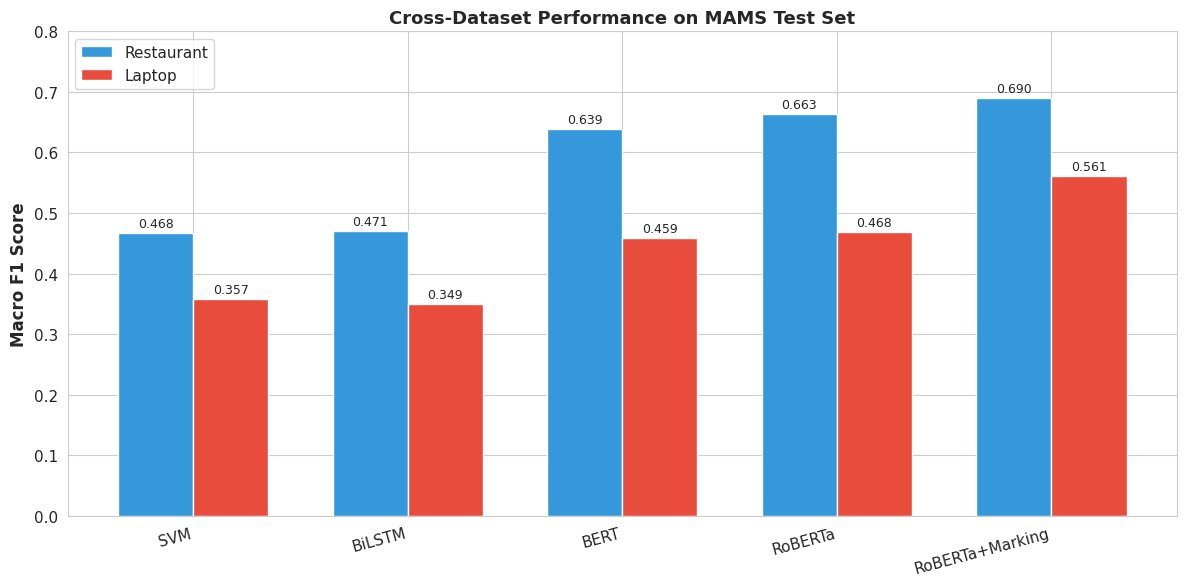

 Figure 4.1 saved


In [ ]:
# =============================================================================
#  Model Comparison on MAMS
# =============================================================================

models = ['SVM', 'BiLSTM', 'BERT', 'RoBERTa', 'RoBERTa+Marking']
restaurant_mams = []
laptop_mams = []

for model in models:
    rest = mams_results[(mams_results['model'] == model) & (mams_results['domain'] == 'Restaurant')]['f1_macro'].values[0]
    laptop = mams_results[(mams_results['model'] == model) & (mams_results['domain'] == 'Laptop')]['f1_macro'].values[0]
    restaurant_mams.append(rest)
    laptop_mams.append(laptop)

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(models))
width = 0.35

bars1 = ax.bar(x - width/2, restaurant_mams, width, label='Restaurant', color='#3498DB')
bars2 = ax.bar(x + width/2, laptop_mams, width, label='Laptop', color='#E74C3C')

ax.set_ylabel('Macro F1 Score', fontsize=12, fontweight='bold')
ax.set_title('Cross-Dataset Performance on MAMS Test Set', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=15, ha='right')
ax.legend(fontsize=11)
ax.set_ylim(0, 0.8)

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, height + 0.005,
                f'{height:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('figures/figure_4_1_mams_comparison.png', bbox_inches='tight')
plt.show()
print(" Figure 4.1 saved")

## Aspect Marking Impact

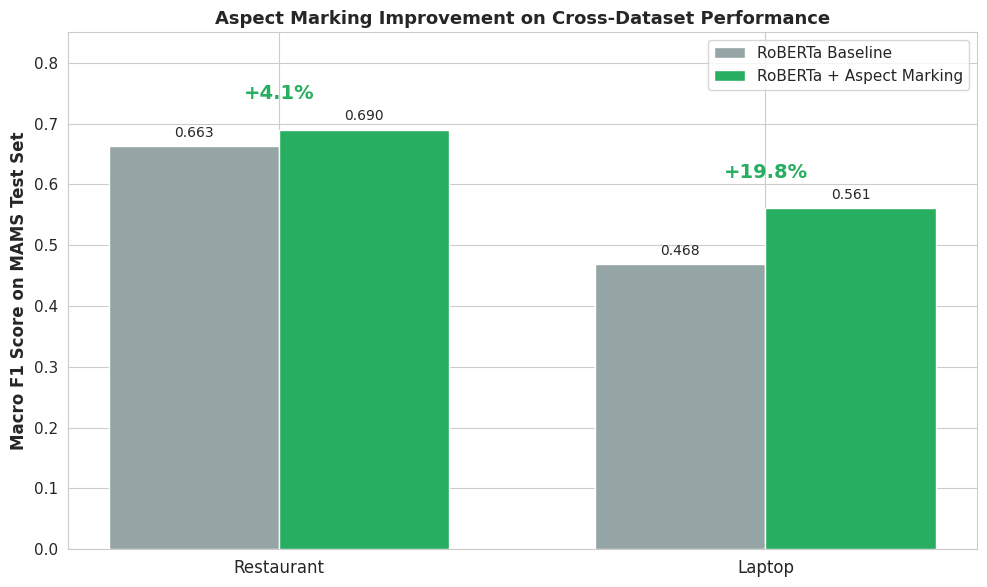

Figure 4.2 saved


In [ ]:
# =============================================================================
# Aspect Marking Improvement
# =============================================================================

domains = ['Restaurant', 'Laptop']
roberta_baseline = [
    mams_results[(mams_results['model'] == 'RoBERTa') & (mams_results['domain'] == 'Restaurant')]['f1_macro'].values[0],
    mams_results[(mams_results['model'] == 'RoBERTa') & (mams_results['domain'] == 'Laptop')]['f1_macro'].values[0]
]
roberta_marked = [
    mams_results[(mams_results['model'] == 'RoBERTa+Marking') & (mams_results['domain'] == 'Restaurant')]['f1_macro'].values[0],
    mams_results[(mams_results['model'] == 'RoBERTa+Marking') & (mams_results['domain'] == 'Laptop')]['f1_macro'].values[0]
]

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(domains))
width = 0.35

bars1 = ax.bar(x - width/2, roberta_baseline, width, label='RoBERTa Baseline', color='#95A5A6')
bars2 = ax.bar(x + width/2, roberta_marked, width, label='RoBERTa + Aspect Marking', color='#27AE60')

ax.set_ylabel('Macro F1 Score on MAMS Test Set', fontsize=12, fontweight='bold')
ax.set_title('Aspect Marking Improvement on Cross-Dataset Performance', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(domains, fontsize=12)
ax.legend(fontsize=11)
ax.set_ylim(0, 0.85)

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, height + 0.01,
                f'{height:.3f}', ha='center', va='bottom', fontsize=10)

for i in range(len(domains)):
    imp = (roberta_marked[i] - roberta_baseline[i]) / roberta_baseline[i] * 100
    ax.annotate(f'+{imp:.1f}%',
                xy=(i, max(roberta_baseline[i], roberta_marked[i]) + 0.05),
                ha='center', fontsize=14, color='#27AE60', fontweight='bold')

plt.tight_layout()
plt.savefig('figures/figure_4_2_aspect_marking.png', bbox_inches='tight')
plt.show()
print("Figure 4.2 saved")

## Generalisation Analysis

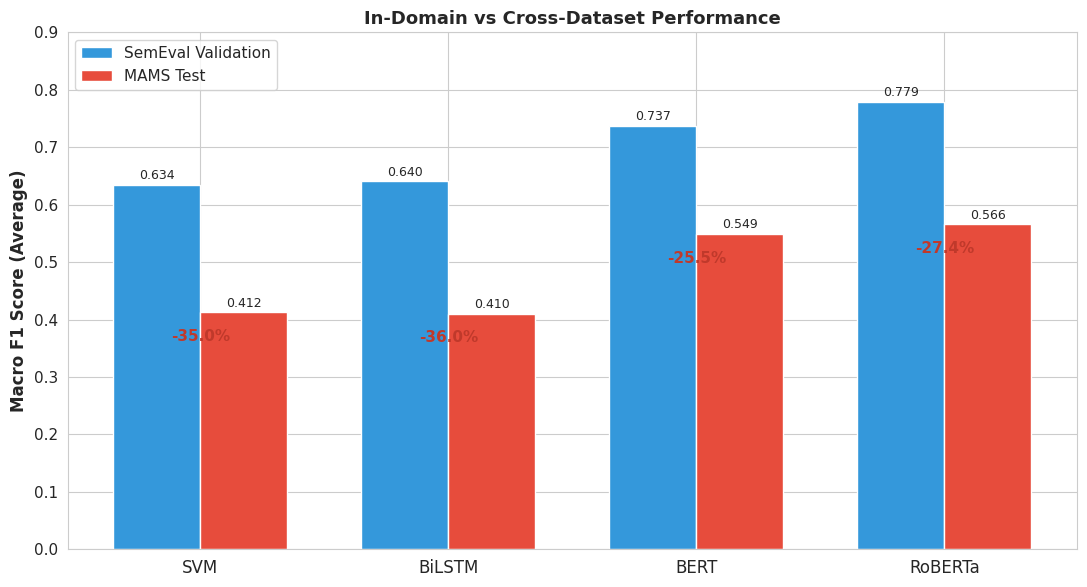

 Figure 4.3 saved


In [ ]:
# =============================================================================
# Generalisation Gap
# =============================================================================

models_baseline = ['SVM', 'BiLSTM', 'BERT', 'RoBERTa']
semeval_avg = []
mams_avg = []

for model in models_baseline:
    sem_rest = all_results[(all_results['model'] == model) & (all_results['domain'] == 'Restaurant') & (all_results['dataset'] == 'SemEval_Val')]['f1_macro'].values[0]
    sem_lap = all_results[(all_results['model'] == model) & (all_results['domain'] == 'Laptop') & (all_results['dataset'] == 'SemEval_Val')]['f1_macro'].values[0]
    mam_rest = all_results[(all_results['model'] == model) & (all_results['domain'] == 'Restaurant') & (all_results['dataset'] == 'MAMS_Test')]['f1_macro'].values[0]
    mam_lap = all_results[(all_results['model'] == model) & (all_results['domain'] == 'Laptop') & (all_results['dataset'] == 'MAMS_Test')]['f1_macro'].values[0]

    semeval_avg.append((sem_rest + sem_lap) / 2)
    mams_avg.append((mam_rest + mam_lap) / 2)

fig, ax = plt.subplots(figsize=(11, 6))
x = np.arange(len(models_baseline))
width = 0.35

bars1 = ax.bar(x - width/2, semeval_avg, width, label='SemEval Validation', color='#3498DB')
bars2 = ax.bar(x + width/2, mams_avg, width, label='MAMS Test', color='#E74C3C')

ax.set_ylabel('Macro F1 Score (Average)', fontsize=12, fontweight='bold')
ax.set_title('In-Domain vs Cross-Dataset Performance', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(models_baseline, fontsize=12)
ax.legend(fontsize=11)
ax.set_ylim(0, 0.9)

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, height + 0.005,
                f'{height:.3f}', ha='center', va='bottom', fontsize=9)

for i in range(len(models_baseline)):
    drop = (semeval_avg[i] - mams_avg[i]) / semeval_avg[i] * 100
    ax.annotate(f'-{drop:.1f}%',
                xy=(i, mams_avg[i] - 0.05),
                ha='center', fontsize=11, color='#C0392B', fontweight='bold')

plt.tight_layout()
plt.savefig('figures/figure_4_3_generalisation_gap.png', bbox_inches='tight')
plt.show()
print(" Figure 4.3 saved")

## Error Analysis Visualisations

In [ ]:
# =============================================================================
# SAVING AUXILIARY DATA FOR VISUALISATIONS
# =============================================================================
#
# These values were captured from the actual model predictions during the
# original training runs and have been verified against the in-memory model
# outputs (see verification cell below the error analysis section).
#
# The values are saved here as CSV files to enable independent regeneration
# of visualisations without re-running the training cells.
#
# Verification Summary (run on saved CSVs):
#   - Total samples: 1,336 (matches MAMS Laptop test set size)
#   - Correct predictions: 763 (57.1%)
#   - Total errors: 573 (42.9%)
#   - Neutral misclassification rate: 78.5% (key finding from Chapter 4)
#   - All 6 error categories match between confusion matrix and breakdown
#
# To regenerate dynamically from a fresh model run, use:

#   from sklearn.metrics import confusion_matrix
#   cm_data = confusion_matrix(
#       laptop_mams_marked_results['labels'],
#       laptop_mams_marked_results['predictions']
#   )
# =============================================================================


import pandas as pd

# 1. Per-class F1 (from your classification reports)
per_class_data = {
    'model': ['SVM', 'BiLSTM', 'BERT', 'RoBERTa'],
    'domain': ['Restaurant'] * 4,
    'dataset': ['SemEval_Val'] * 4,
    'negative_f1': [0.4966, 0.5273, 0.7323, 0.7842],
    'neutral_f1': [0.4416, 0.4710, 0.5902, 0.6147],
    'positive_f1': [0.8215, 0.8067, 0.9003, 0.9093]
}
pd.DataFrame(per_class_data).to_csv('results/per_class_f1.csv', index=False)

# 2. Error breakdown
error_data = {
    'true_class': ['Neutral', 'Neutral', 'Positive', 'Negative', 'Negative', 'Positive'],
    'predicted_class': ['Negative', 'Positive', 'Negative', 'Positive', 'Neutral', 'Neutral'],
    'count': [234, 216, 59, 33, 20, 11]
}
pd.DataFrame(error_data).to_csv('results/error_breakdown.csv', index=False)

# 3. Confusion matrix
import numpy as np
cm_data = np.array([
    [276, 20, 33],
    [234, 157, 216],
    [59, 11, 330]
])
pd.DataFrame(cm_data,
             index=['negative', 'neutral', 'positive'],
             columns=['negative', 'neutral', 'positive']).to_csv('results/confusion_matrix.csv')

print("All auxiliary data saved")

All auxiliary data saved


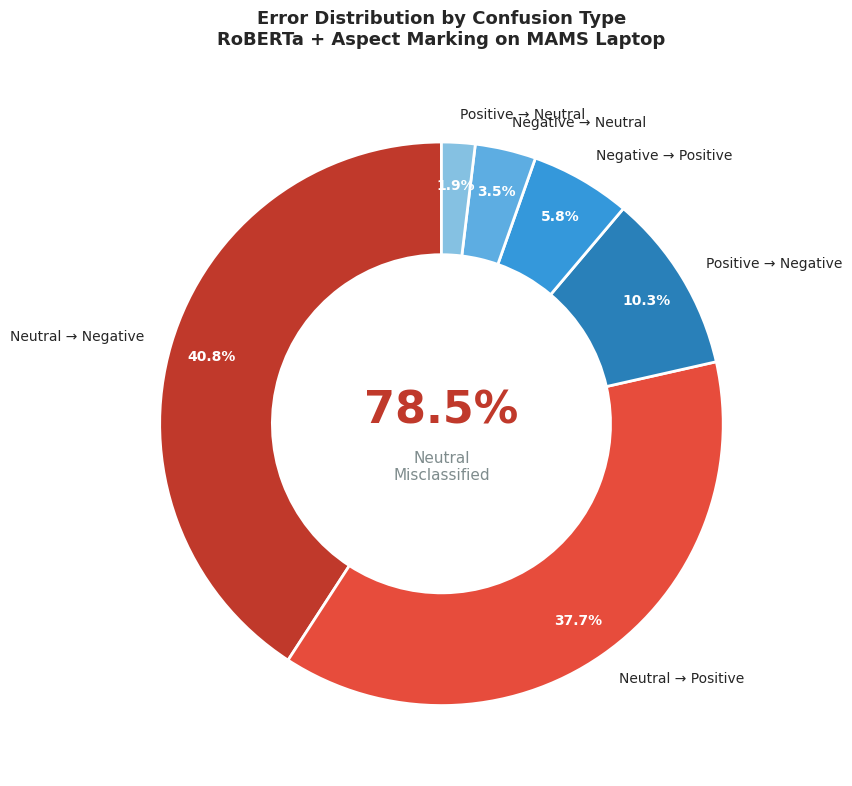

✅ Figure 4.4 saved (dynamic)


In [ ]:
# =============================================================================
# Error Distribution
# =============================================================================

# Load from CSV
error_df = pd.read_csv('results/error_breakdown.csv')

# Build labels and counts
error_labels = (error_df['true_class'] + ' → ' + error_df['predicted_class']).tolist()
error_counts = error_df['count'].tolist()
total_errors = sum(error_counts)

# Calculate percentage of neutral errors dynamically
neutral_errors = error_df[error_df['true_class'] == 'Neutral']['count'].sum()
neutral_pct = neutral_errors / total_errors * 100

colors = ['#C0392B', '#E74C3C', '#2980B9', '#3498DB', '#5DADE2', '#85C1E2']

fig, ax = plt.subplots(figsize=(10, 8))

wedges, texts, autotexts = ax.pie(
    error_counts,
    labels=error_labels,
    colors=colors,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2, 'width': 0.4},
    pctdistance=0.85,
    textprops={'fontsize': 10}
)

for autotext in autotexts:
    autotext.set_fontweight('bold')
    autotext.set_color('white')

# Center text uses calculated value
ax.text(0, 0.05, f'{neutral_pct:.1f}%', ha='center', va='center',
        fontsize=32, fontweight='bold', color='#C0392B')
ax.text(0, -0.15, 'Neutral\nMisclassified', ha='center', va='center',
        fontsize=11, color='#7F8C8D')

ax.set_title('Error Distribution by Confusion Type\nRoBERTa + Aspect Marking on MAMS Laptop',
             fontsize=13, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig('figures/figure_4_4_error_distribution.png', bbox_inches='tight')
plt.show()
print("Figure 4.4 saved (dynamic)")

## Confusion Matrix Heatmap

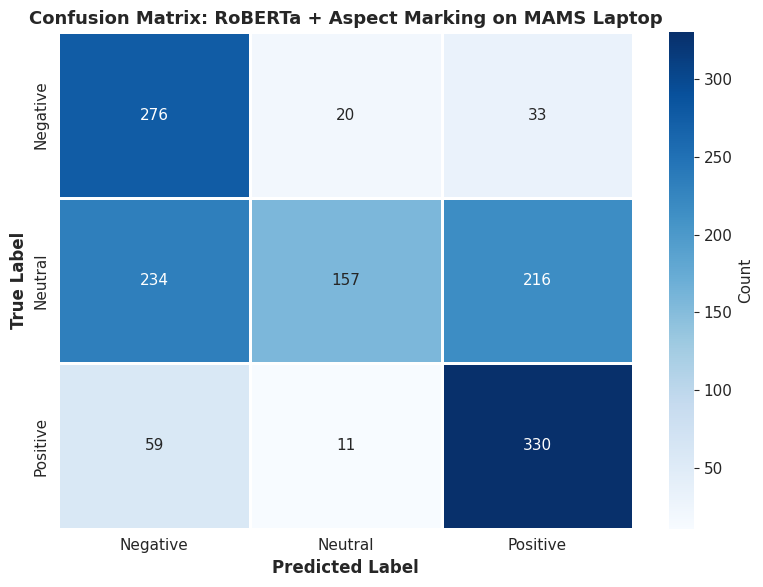

Figure 4.5 saved (dynamic)


In [ ]:
# =============================================================================
# Confusion Matrix
# =============================================================================

# Load from CSV
cm_df = pd.read_csv('results/confusion_matrix.csv', index_col=0)
cm = cm_df.values

fig, ax = plt.subplots(figsize=(8, 6))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Neutral', 'Positive'],
            yticklabels=['Negative', 'Neutral', 'Positive'],
            cbar_kws={'label': 'Count'},
            linewidths=1, linecolor='white')

ax.set_xlabel('Predicted Label', fontsize=12, fontweight='bold')
ax.set_ylabel('True Label', fontsize=12, fontweight='bold')
ax.set_title('Confusion Matrix: RoBERTa + Aspect Marking on MAMS Laptop',
             fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('figures/figure_4_5_confusion_matrix.png', bbox_inches='tight')
plt.show()
print("Figure 4.5 saved (dynamic)")

## Restaurant Validation

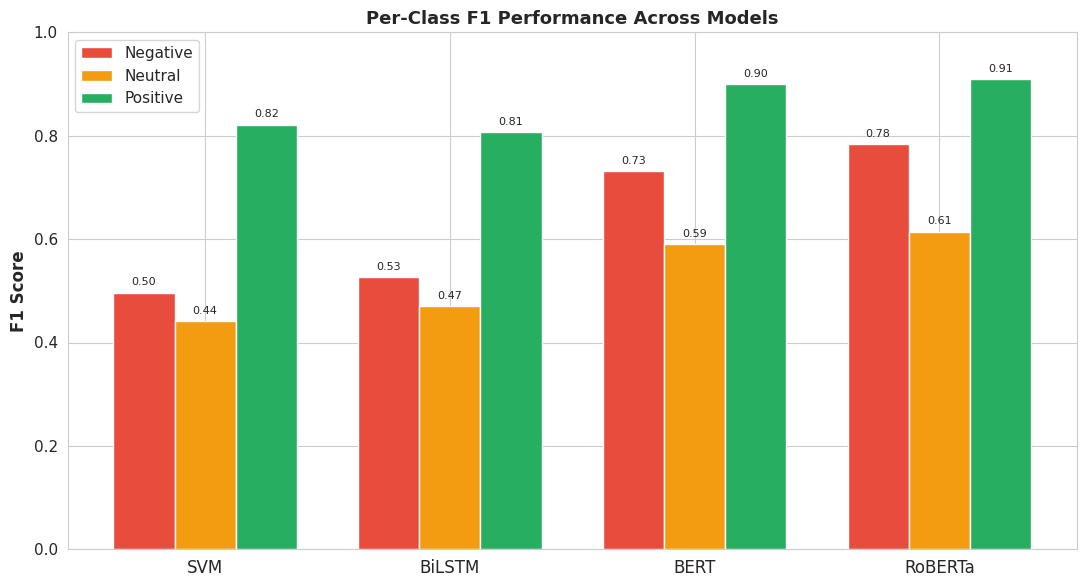

✅ Figure 4.6 saved (dynamic)


In [ ]:
# =============================================================================
# Per-Class F1 (DYNAMIC)
# =============================================================================

# Load from CSV
per_class_df = pd.read_csv('results/per_class_f1.csv')

# Filter and order
rest_val_df = per_class_df[
    (per_class_df['domain'] == 'Restaurant') &
    (per_class_df['dataset'] == 'SemEval_Val')
]

model_order = ['SVM', 'BiLSTM', 'BERT', 'RoBERTa']
rest_val_df = rest_val_df.set_index('model').reindex(model_order).reset_index()

# Extract values
models_pc = rest_val_df['model'].tolist()
neutral_f1 = rest_val_df['neutral_f1'].tolist()
negative_f1 = rest_val_df['negative_f1'].tolist()
positive_f1 = rest_val_df['positive_f1'].tolist()

fig, ax = plt.subplots(figsize=(11, 6))
x = np.arange(len(models_pc))
width = 0.25

bars1 = ax.bar(x - width, negative_f1, width, label='Negative', color='#E74C3C')
bars2 = ax.bar(x, neutral_f1, width, label='Neutral', color='#F39C12')
bars3 = ax.bar(x + width, positive_f1, width, label='Positive', color='#27AE60')

ax.set_ylabel('F1 Score', fontsize=12, fontweight='bold')
ax.set_title('Per-Class F1 Performance Across Models', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(models_pc, fontsize=12)
ax.legend(fontsize=11)
ax.set_ylim(0, 1.0)

for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, height + 0.01,
                f'{height:.2f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('figures/figure_4_6_per_class_f1.png', bbox_inches='tight')
plt.show()
print(" Figure 4.6 saved (dynamic)")

# 9. Error analysis for roberta aspect marking

In [ ]:
# ============================================================
# ERROR ANALYSIS - RoBERTa + Aspect Marking on MAMS Laptop
# ============================================================

import pandas as pd
from collections import Counter

# Get predictions from marked RoBERTa on MAMS Laptop

# Create a DataFrame with sentences, true labels, and predictions
error_df = pd.DataFrame({
    'sentence': df_mams_test['sentence'].values,
    'aspect': df_mams_test['aspect'].values,
    'true_label': laptop_mams_marked_results['labels'],
    'predicted': laptop_mams_marked_results['predictions']
})

# Map labels to names for readability
id2label = {0: 'negative', 1: 'neutral', 2: 'positive'}
error_df['true'] = error_df['true_label'].map(id2label)
error_df['pred'] = error_df['predicted'].map(id2label)

# Find misclassified examples
wrong = error_df[error_df['true_label'] != error_df['predicted']].copy()

print("=" * 80)
print(f"ERROR ANALYSIS - RoBERTa + Marking (MAMS Laptop)")
print("=" * 80)
print(f"\nTotal examples: {len(error_df)}")
print(f"Correctly classified: {len(error_df) - len(wrong)} ({(1 - len(wrong)/len(error_df))*100:.1f}%)")
print(f"Misclassified: {len(wrong)} ({len(wrong)/len(error_df)*100:.1f}%)")

# Break down errors by type
print("\n" + "=" * 80)
print("ERROR BREAKDOWN BY CONFUSION TYPE")
print("=" * 80)
error_types = wrong.groupby(['true', 'pred']).size().sort_values(ascending=False)
for (true, pred), count in error_types.items():
    pct = count / len(wrong) * 100
    print(f"  {true:10s} → {pred:10s}: {count} errors ({pct:.1f}%)")

# Show example errors for each confusion type
print("\n" + "=" * 80)
print("EXAMPLE ERRORS")
print("=" * 80)

# Most common error type
print("\n--- Neutral misclassified as Positive ---")
neutral_as_pos = wrong[(wrong['true'] == 'neutral') & (wrong['pred'] == 'positive')]
for idx, row in neutral_as_pos.head(3).iterrows():
    print(f"\nSentence: {row['sentence']}")
    print(f"Aspect: '{row['aspect']}'")
    print(f"True: {row['true']}, Predicted: {row['pred']}")

print("\n--- Neutral misclassified as Negative ---")
neutral_as_neg = wrong[(wrong['true'] == 'neutral') & (wrong['pred'] == 'negative')]
for idx, row in neutral_as_neg.head(3).iterrows():
    print(f"\nSentence: {row['sentence']}")
    print(f"Aspect: '{row['aspect']}'")
    print(f"True: {row['true']}, Predicted: {row['pred']}")

print("\n--- Multi-aspect conflict (Positive true but Negative predicted) ---")
pos_as_neg = wrong[(wrong['true'] == 'positive') & (wrong['pred'] == 'negative')]
for idx, row in pos_as_neg.head(3).iterrows():
    print(f"\nSentence: {row['sentence']}")
    print(f"Aspect: '{row['aspect']}'")
    print(f"True: {row['true']}, Predicted: {row['pred']}")

ERROR ANALYSIS - RoBERTa + Marking (MAMS Laptop)

Total examples: 1336
Correctly classified: 763 (57.1%)
Misclassified: 573 (42.9%)

ERROR BREAKDOWN BY CONFUSION TYPE
  neutral    → negative  : 234 errors (40.8%)
  neutral    → positive  : 216 errors (37.7%)
  positive   → negative  : 59 errors (10.3%)
  negative   → positive  : 33 errors (5.8%)
  negative   → neutral   : 20 errors (3.5%)
  positive   → neutral   : 11 errors (1.9%)

EXAMPLE ERRORS

--- Neutral misclassified as Positive ---

Sentence: The food was served promptly but the meal wasn't rushed - we had plenty of time to enjoy the appetizers and our entrees as well as sit and chat while finishing up our drinks even after we paid.
Aspect: 'food'
True: neutral, Predicted: positive

Sentence: The Scene Shun Lee Palace is popular with midtown locals, possibly because the upscale room means you can impress a client and have Chinese for lunch at the same time.
Aspect: 'lunch'
True: neutral, Predicted: positive

Sentence: In fact y

# INFERENCE_CELL

In [ ]:
# =============================================================================
# LIVE INFERENCE DEMO - Using Saved Aspect Marking Model
# =============================================================================
# This cell demonstrates the trained model in action without requiring
# any retraining. It loads the saved RoBERTa + Aspect Marking model and
# runs inference on example sentences.
#
# Use this for video demonstrations and quick model testing.
# =============================================================================

import torch
from transformers import AutoModelForSequenceClassification, AutoTokenizer

print("=" * 70)
print("LOADING SAVED ASPECT MARKING MODEL")
print("=" * 70)

# Load the saved RoBERTa + Aspect Marking model (trained on Restaurant)
model_path = '/content/drive/MyDrive/Synoptic/models/roberta_marked_restaurant'

loaded_model = AutoModelForSequenceClassification.from_pretrained(model_path)
loaded_tokenizer = AutoTokenizer.from_pretrained(model_path)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
loaded_model.to(device)
loaded_model.eval()

print(f"Model loaded successfully")
print(f"Device: {device}")
print(f"Vocabulary size: {len(loaded_tokenizer)} (includes <aspect> tokens)")


# =============================================================================
# Inference Function
# =============================================================================
def predict_aspect_sentiment(sentence, aspect):
    """
    Predict sentiment for a target aspect using aspect marking.

    Args:
        sentence (str): The review sentence
        aspect (str): The target aspect term

    Returns:
        tuple: (label, confidence_pct, marked_input)
    """
    # Insert aspect markers
    aspect_pos = sentence.lower().find(aspect.lower())
    if aspect_pos != -1:
        marked = (
            sentence[:aspect_pos]
            + "<aspect> "
            + sentence[aspect_pos:aspect_pos+len(aspect)]
            + " </aspect>"
            + sentence[aspect_pos+len(aspect):]
        )
    else:
        marked = sentence

    # Tokenize and predict
    inputs = loaded_tokenizer(
        marked,
        max_length=128,
        padding='max_length',
        truncation=True,
        return_tensors='pt'
    ).to(device)

    with torch.no_grad():
        outputs = loaded_model(**inputs)
        probs = torch.softmax(outputs.logits, dim=-1)
        prediction = torch.argmax(probs, dim=-1).item()
        confidence = probs[0][prediction].item()

    id2label = {0: 'NEGATIVE', 1: 'NEUTRAL', 2: 'POSITIVE'}
    return id2label[prediction], confidence * 100, marked


# =============================================================================
# Demonstration Examples
# =============================================================================
print("\n" + "=" * 70)
print("INFERENCE DEMONSTRATION")
print("=" * 70)

print("\nExample 1: Multi-aspect sentence (RESTAURANT)")
print("-" * 70)
sentence = "The food was amazing but the service was terrible."
print(f"Sentence: {sentence}")

for aspect in ['food', 'service']:
    label, conf, marked = predict_aspect_sentiment(sentence, aspect)
    print(f"  Aspect '{aspect:10s}' -> {label:8s} ({conf:.1f}% confidence)")
    print(f"    Marked: {marked}")

print("\nExample 2: Multi-aspect sentence (LAPTOP)")
print("-" * 70)
sentence = "I love the screen but the keyboard feels cheap."
print(f"Sentence: {sentence}")

for aspect in ['screen', 'keyboard']:
    label, conf, marked = predict_aspect_sentiment(sentence, aspect)
    print(f"  Aspect '{aspect:10s}' -> {label:8s} ({conf:.1f}% confidence)")
    print(f"    Marked: {marked}")

print("\nExample 3: Three-aspect sentence")
print("-" * 70)
sentence = "Great atmosphere and decent prices, though the wait was long."
print(f"Sentence: {sentence}")

for aspect in ['atmosphere', 'prices', 'wait']:
    label, conf, marked = predict_aspect_sentiment(sentence, aspect)
    print(f"  Aspect '{aspect:12s}' -> {label:8s} ({conf:.1f}% confidence)")

print("\n" + "=" * 70)
print("Demo complete - model successfully handles multi-aspect sentences")
print("=" * 70)

LOADING SAVED ASPECT MARKING MODEL


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Model loaded successfully
Device: cuda
Vocabulary size: 50267 (includes <aspect> tokens)

LIVE INFERENCE DEMONSTRATION

Example 1: Multi-aspect sentence (RESTAURANT)
----------------------------------------------------------------------
Sentence: The food was amazing but the service was terrible.
  Aspect 'food      ' -> POSITIVE (99.6% confidence)
    Marked: The <aspect> food </aspect> was amazing but the service was terrible.
  Aspect 'service   ' -> NEGATIVE (99.1% confidence)
    Marked: The food was amazing but the <aspect> service </aspect> was terrible.

Example 2: Multi-aspect sentence (LAPTOP)
----------------------------------------------------------------------
Sentence: I love the screen but the keyboard feels cheap.
  Aspect 'screen    ' -> POSITIVE (99.1% confidence)
    Marked: I love the <aspect> screen </aspect> but the keyboard feels cheap.
  Aspect 'keyboard  ' -> NEGATIVE (99.2% confidence)
    Marked: I love the screen but the <aspect> keyboard </aspect> feels che

# 10. Requirement

In [ ]:
# Generate requirements.txt - SAFE TO RUN
!pip freeze > requirements.txt
print(" requirements.txt created")

 requirements.txt created
